# Local Flip Compression Geometry (v2)

Reads `data/all_settings_master_v2.tsv` and writes paper figures to `_NeurIPS_2026_/figs/comp_analysis`.


In [59]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator, MultipleLocator
import pandas as pd


In [60]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'analysis' / 'visualization' / 'comp_analysis').is_dir() and (candidate / 'results' / 'figures').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate project root from {start}')


NOTEBOOK_DIR = find_project_root() / 'analysis' / 'visualization' / 'comp_analysis'
PAPER_ROOT = NOTEBOOK_DIR.parents[2]
DATA_PATH = NOTEBOOK_DIR / 'data' / 'all_settings_master_v2.tsv'
OUT_DIR = PAPER_ROOT / 'results' / 'figures' / 'comp_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

KEEP_SETTINGS = ['awq_native', 'wanda_2_4', 'wanda_4_8', 'wanda_unstructured']
PLOT_ORDER = ['awq_native', 'wanda_unstructured', 'wanda_4_8', 'wanda_2_4']
COMPONENTS = ['block_out', 'attn_out', 'mlp_out']
PLOT_PARALLEL_ERROR = False

DISPLAY_NAME = {
    'awq_native': 'Quantization',
    'wanda_2_4': '2:4',
    'wanda_4_8': '4:8',
    'wanda_unstructured': 'Unstructured',
}

COMPONENT_TITLE = {
    'block_out': 'Block',
    'attn_out': 'Attention',
    'mlp_out': 'MLP',
}

STYLE_MAP = {
    'awq_native': {'color': '#4C78A8', 'marker': 'o'},
    'wanda_unstructured': {'color': '#222222', 'marker': 's'},
    'wanda_4_8': {'color': '#F58518', 'marker': '^'},
    'wanda_2_4': {'color': '#E45756', 'marker': 'D'},
}

PLOT_RC = {
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.05,
    'axes.labelsize': 23,
    'axes.titlesize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
}

X_LABEL_FONTSIZE = 23
Y_LABEL_FONTSIZE = 22
Y_LABEL_PAD = 6
LEGEND_BBOX = (0.5, 0.985)
X_LIM_PAD = 0.8
OUTPUT_SUFFIXES = ('pdf',)


In [61]:
def load_local_rows():
    df = pd.read_csv(DATA_PATH, sep='	')
    if 'focus_layer' in df.columns:
        df = df[df['layer'] == df['focus_layer']].copy()
    for col in (
        'error_over_base_update',
        'error_over_base_update_std',
        'para_over_base_update',
        'para_over_base_update_std',
        'perp_over_base_update',
        'perp_over_base_update_std',
        'base_update_over_hidden_state',
        'base_update_over_hidden_state_std',
        'hidden_state_norm',
        'hidden_state_norm_std',
    ):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # These are baseline-only quantities. If a setting was aggregated from an
    # older run, borrow the value from another setting with the same component/layer.
    baseline_cols = [
        'hidden_state_norm',
        'hidden_state_norm_std',
        'base_update_over_hidden_state',
        'base_update_over_hidden_state_std',
    ]
    for col in baseline_cols:
        if col in df.columns:
            fill = df.groupby(['component', 'layer'])[col].transform(
                lambda s: s.dropna().iloc[0] if s.notna().any() else float('nan')
            )
            df[col] = df[col].fillna(fill)
    return df


def exclude_edge_layers(df):
    layers = sorted(df['layer'].dropna().unique().tolist())
    if len(layers) < 3:
        return df
    return df[(df['layer'] >= layers[1]) & (df['layer'] <= layers[-2])].copy()


def nice_ylim(series, pad=0.12):
    s = pd.to_numeric(series, errors='coerce').dropna()
    if s.empty:
        return None
    hi = float(s.quantile(0.98))
    if hi <= 0:
        hi = float(s.max())
    return (0.0, hi * (1.0 + pad))


def centered_ylim(lo_series, hi_series=None, pad=0.16, min_span=0.05):
    lo_s = pd.to_numeric(lo_series, errors='coerce').dropna()
    hi_s = lo_s if hi_series is None else pd.to_numeric(hi_series, errors='coerce').dropna()
    if lo_s.empty or hi_s.empty:
        return None
    lo = float(lo_s.quantile(0.02))
    hi = float(hi_s.quantile(0.98))
    if hi < lo:
        lo, hi = hi, lo
    span = max(hi - lo, min_span)
    center = 0.5 * (lo + hi)
    half = 0.5 * span * (1.0 + pad)
    return (center - half, center + half)


# Manual y-axis limits for paper-facing figures.
# These reserve headroom for the in-axes legend and keep panels stable.
Y_LIM = {
    ('orthogonal_error', 'block_out'): (0.0, 0.78),
    ('orthogonal_error', 'attn_out'): (0.0, 2.05),
    ('orthogonal_error', 'mlp_out'): (0.0, 0.68),
    ('baseline_update_ratio', 'block_out'): (0.2, 0.7),
    ('baseline_update_ratio', 'attn_out'): (0.0, 0.4),
    ('baseline_update_ratio', 'mlp_out'): (0.1, 0.7),
}

Y_TICK_STEP = {
    ('orthogonal_error', 'block_out'): 0.2,
    ('orthogonal_error', 'attn_out'): 0.5,
    ('orthogonal_error', 'mlp_out'): 0.2,
    ('baseline_update_ratio', 'block_out'): 0.1,
    ('baseline_update_ratio', 'attn_out'): 0.1,
    ('baseline_update_ratio', 'mlp_out'): 0.2,
}

TOTAL_Y_LIM = {
    ('total_error', 'block_out'): (0.0, 0.86),
    ('total_error', 'attn_out'): (0.0, 2.05),
    ('total_error', 'mlp_out'): (0.0, 0.78),
}

TOTAL_Y_TICK_STEP = {
    ('total_error', 'block_out'): 0.2,
    ('total_error', 'attn_out'): 0.5,
    ('total_error', 'mlp_out'): 0.2,
}

PARA_Y_LIM = {
    ('parallel_error', 'block_out'): (0.0, 0.62),
    ('parallel_error', 'attn_out'): (0.0, 0.58),
    ('parallel_error', 'mlp_out'): (0.0, 0.68),
}

PARA_Y_TICK_STEP = {
    ('parallel_error', 'block_out'): 0.2,
    ('parallel_error', 'attn_out'): 0.2,
    ('parallel_error', 'mlp_out'): 0.2,
}


def apply_y_axis(ax, ylim, tick_step):
    if ylim is not None:
        ax.set_ylim(*ylim)
    if tick_step is not None:
        ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


def apply_layer_x_axis(ax, layers, nbins):
    if layers:
        ax.set_xlim(min(layers) - X_LIM_PAD, max(layers) + X_LIM_PAD)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=nbins, integer=True))


In [62]:
df = load_local_rows()
print(f'Loaded: {DATA_PATH}')
print(f'Rows after local focus-layer filter: {len(df)}')
print('Settings:', sorted(df['setting'].dropna().unique().tolist()))
print('\nhidden_state_norm non-NaN counts:')
print(df.groupby('setting')['hidden_state_norm'].apply(lambda s: int(s.notna().sum())).to_string())

df.head()


Loaded: analysis/visualization/comp_analysis/data/all_settings_master_v2.tsv
Rows after local focus-layer filter: 432
Settings: ['awq_native', 'wanda_2_4', 'wanda_4_8', 'wanda_unstructured']

hidden_state_norm non-NaN counts:
setting
awq_native            108
wanda_2_4             108
wanda_4_8             108
wanda_unstructured    108


,setting,method,focus_layer,component,layer,alpha,alpha_std,para_abs,para_abs_std,perp_abs,...,perp_over_base_update,perp_over_base_update_std,perp_ratio_to_base_update,perp_ratio_to_base_update_std,hidden_state_norm,hidden_state_norm_std,base_update_over_hidden_state,base_update_over_hidden_state_std,count,run_dir
0,awq_native,awq_native_l0,0.0,attn_out,0,-0.012054,0.004226,0.045195,0.014165,0.197914,...,0.053224,0.015450,0.942061,0.040793,1.038114,0.085460,3.761556,0.699389,12.0,/mnt/bn/seed-aws-va/shwai.he/demystifying-tran...
1,awq_native,awq_native_l0,0.0,block_out,0,-0.029195,0.006665,0.224219,0.052015,0.450204,...,0.055177,0.019039,0.731631,0.157777,1.038114,0.085460,7.489798,0.670775,12.0,/mnt/bn/seed-aws-va/shwai.he/demystifying-tran...
2,awq_native,awq_native_l0,0.0,mlp_out,0,-0.043446,0.010500,0.198191,0.046374,0.403549,...,0.077300,0.016661,0.726535,0.151636,3.952476,0.438856,1.312618,0.674883,12.0,/mnt/bn/seed-aws-va/shwai.he/demystifying-tran...
3,awq_native,awq_native_l1,1.0,attn_out,1,-0.011757,0.007656,0.032102,0.024007,0.224918,...,0.086891,0.006394,0.975923,0.024779,7.839272,1.301879,0.332317,0.025196,12.0,/mnt/bn/seed-aws-va/shwai.he/demystifying-tran...
4,awq_native,awq_native_l1,1.0,block_out,1,-0.016360,0.011637,0.062534,0.045191,0.333386,...,0.096165,0.009983,0.961636,0.030694,7.839272,1.301879,0.429811,0.044633,12.0,/mnt/bn/seed-aws-va/shwai.he/demystifying-tran...


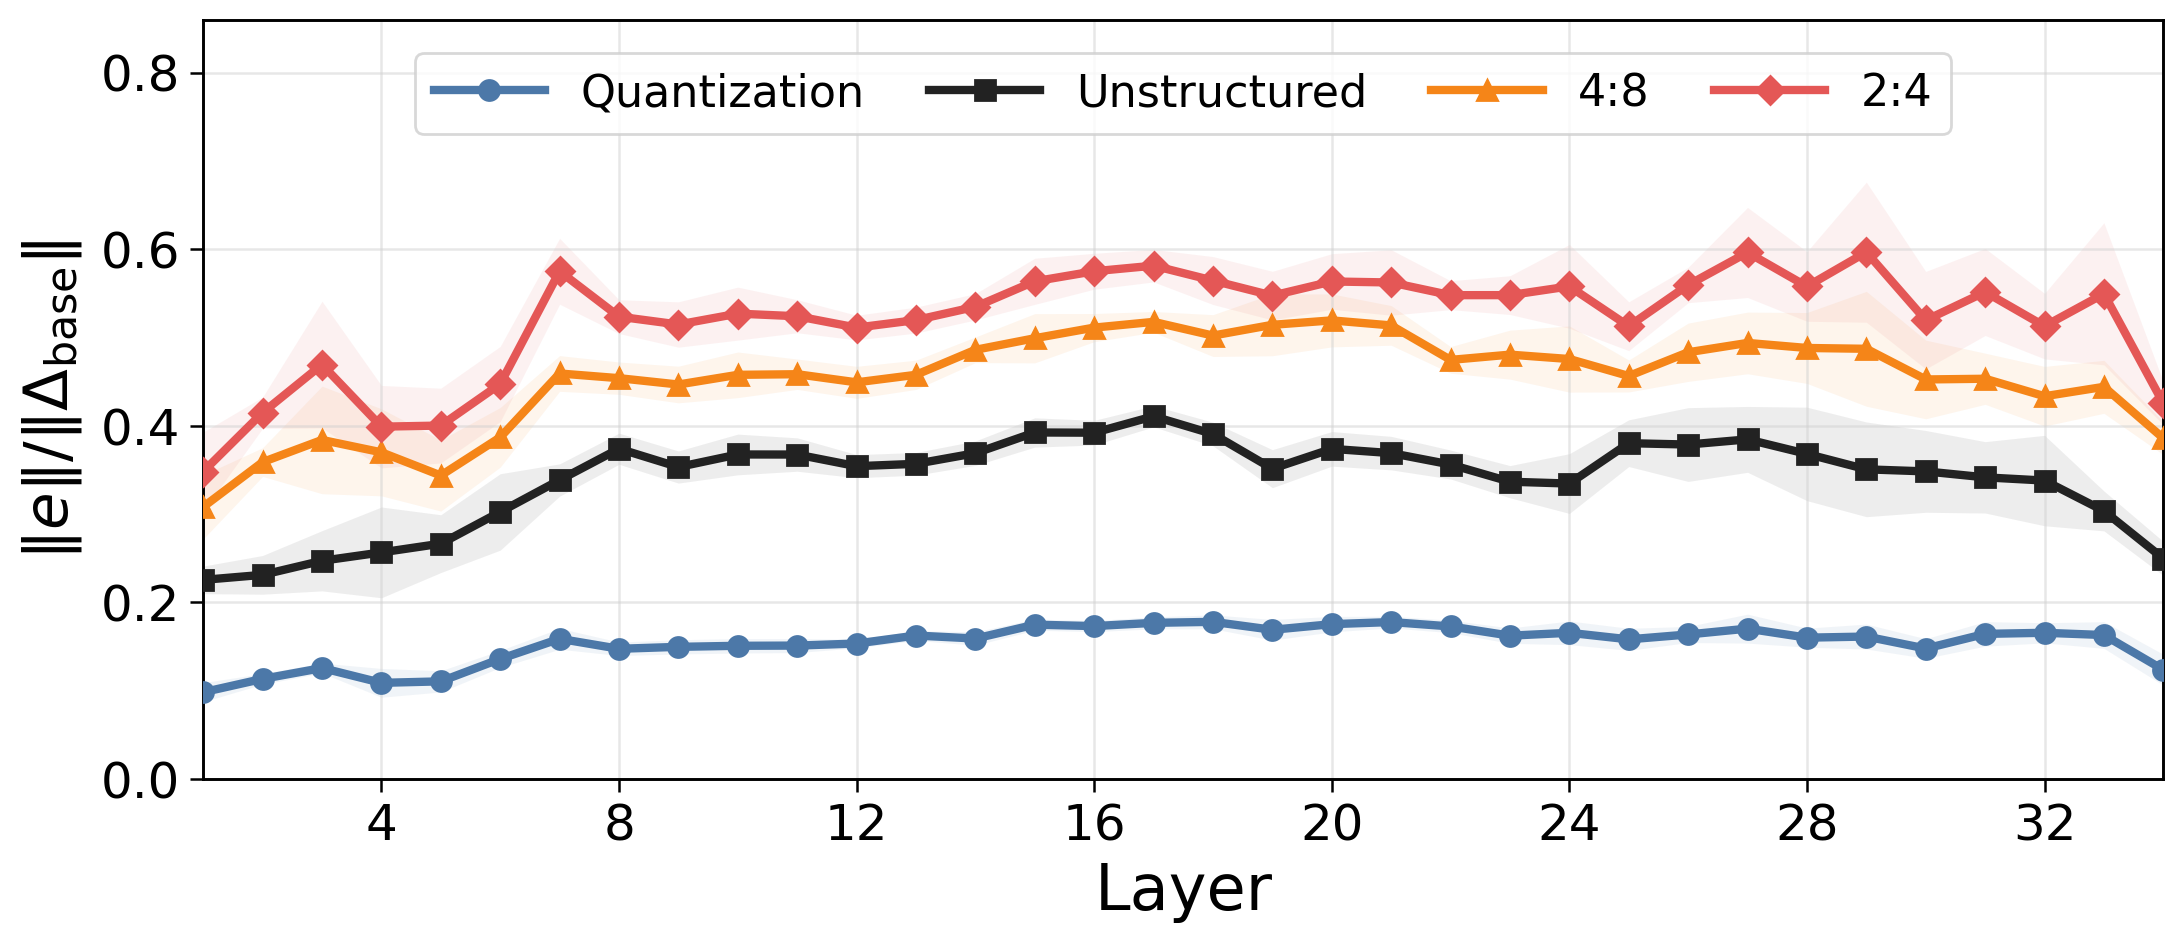

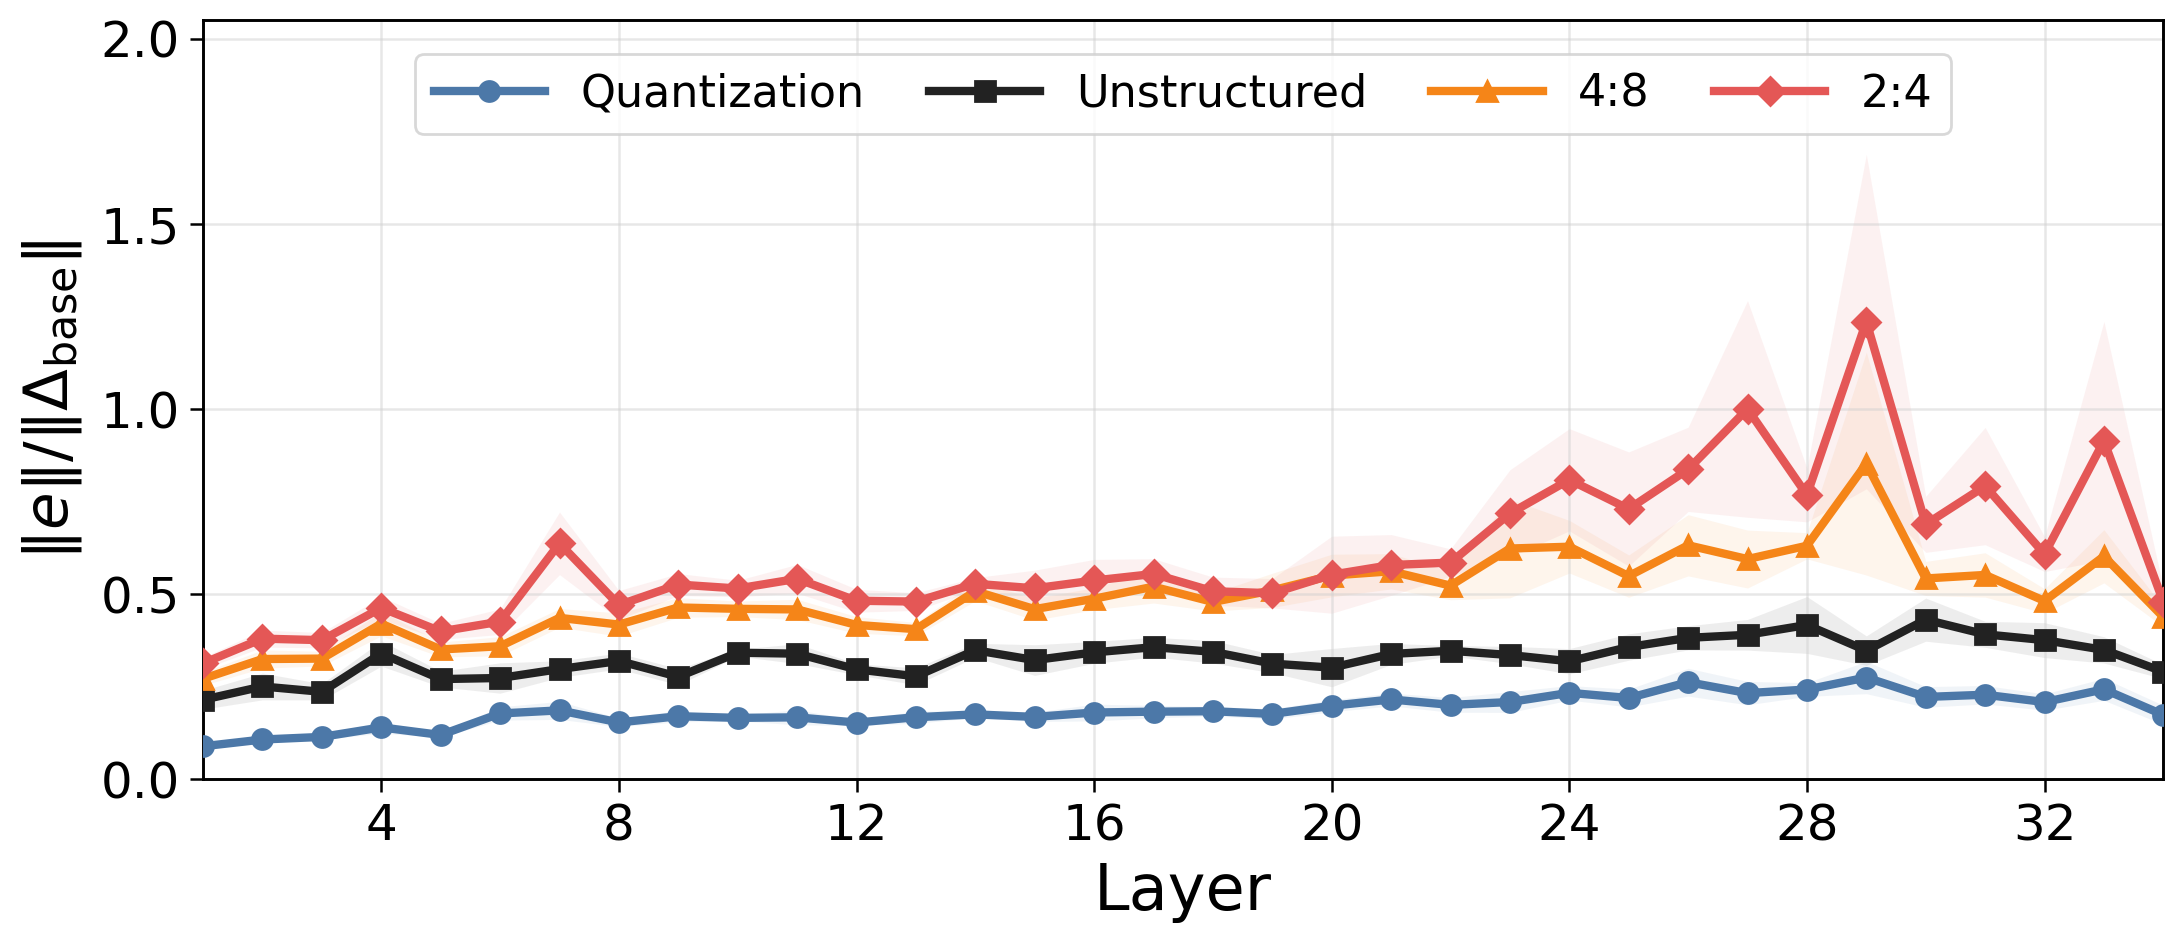

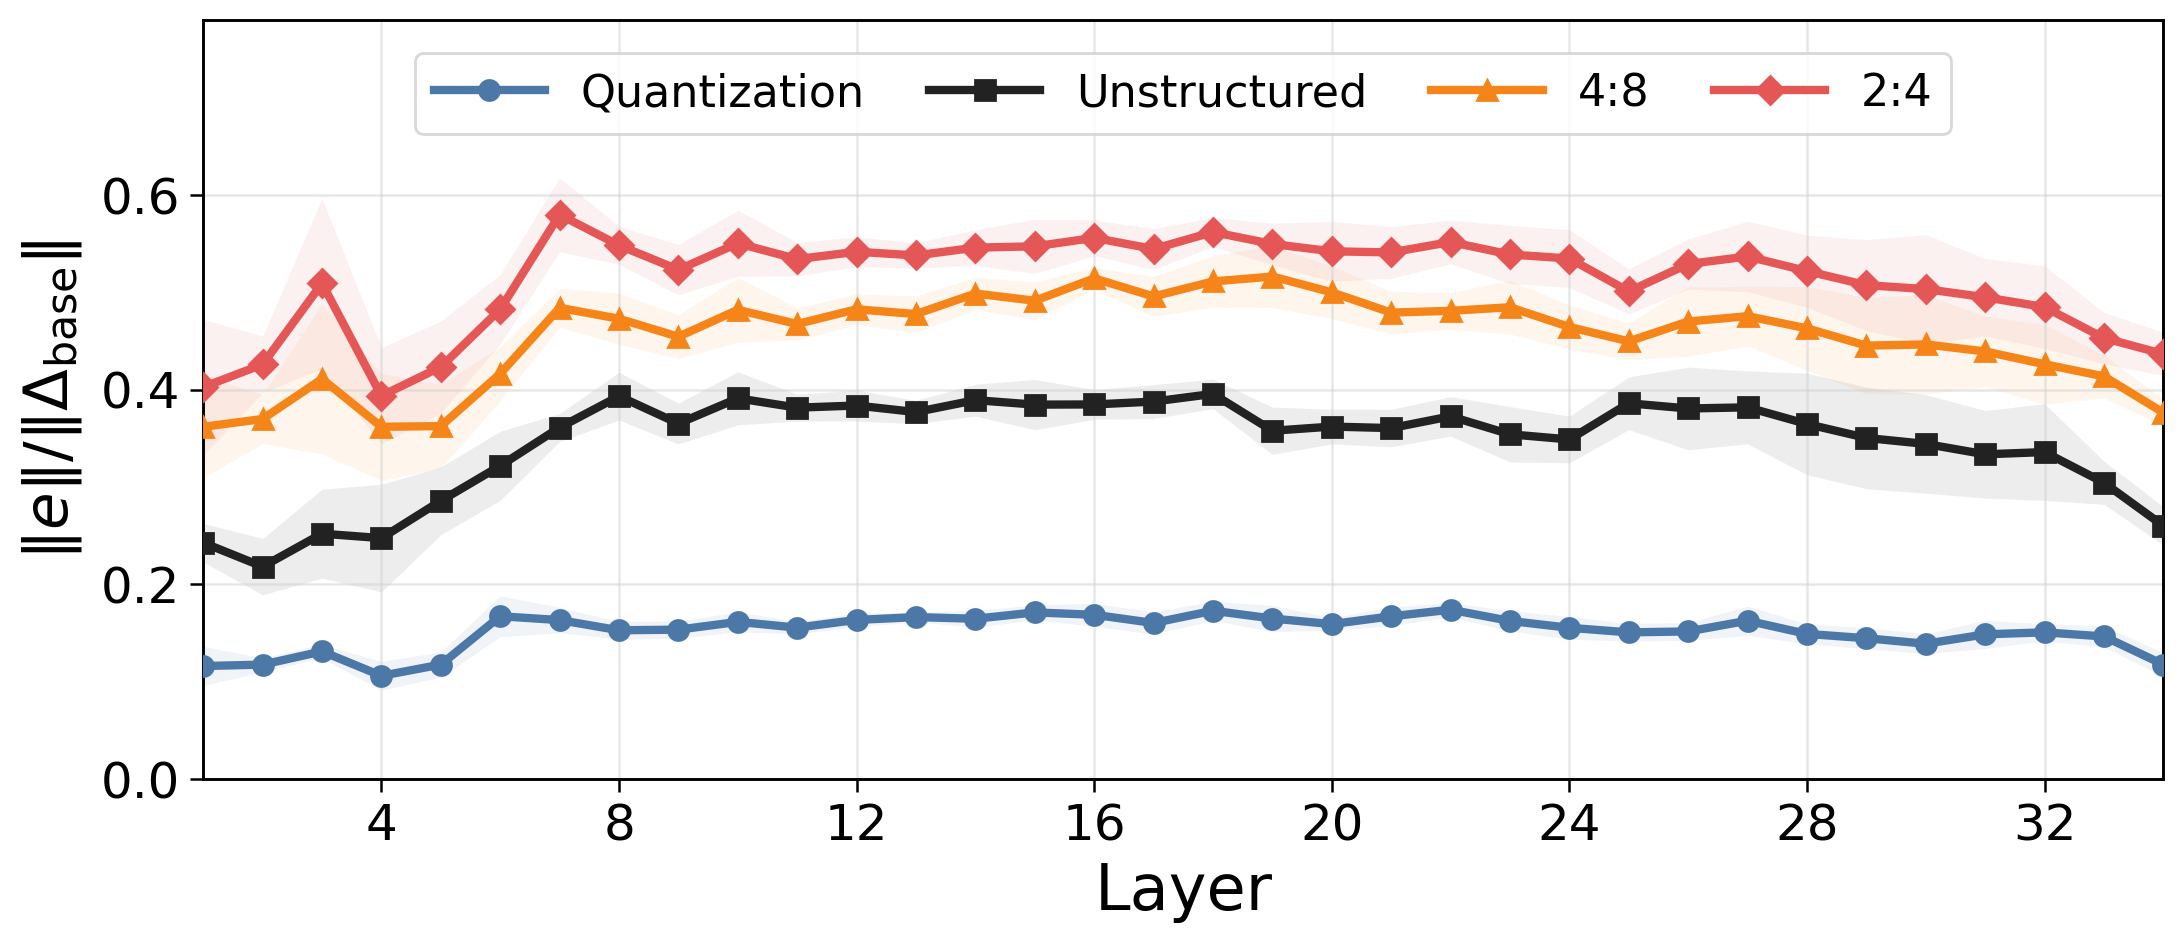

Saved: figs/comp_analysis/local_flip_compare-block_out-error_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-attn_out-error_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-mlp_out-error_over_base_update.pdf


In [63]:
def plot_total_error(df):
    metric = 'error_over_base_update'
    ylabel = r'$\|e\| / \|\Delta_{\mathrm{base}}\|$'
    d_all = exclude_edge_layers(df[df['setting'].isin(KEEP_SETTINGS)].copy())
    saved = []

    for comp in COMPONENTS:
        d = d_all[d_all['component'] == comp].copy()
        if d.empty or d[metric].notna().sum() == 0:
            continue

        with plt.rc_context(PLOT_RC):
            fig, ax = plt.subplots(figsize=(10.8, 4.6), dpi=200, constrained_layout=True)
            valid_settings = [s for s in PLOT_ORDER if d[d['setting'] == s][metric].notna().any()]

            for setting in valid_settings:
                g = d[d['setting'] == setting].sort_values('layer')
                style = STYLE_MAP.get(setting, {'color': '#4C78A8', 'marker': 'o'})
                line = ax.plot(
                    g['layer'],
                    g[metric],
                    color=style['color'],
                    marker=style['marker'],
                    linewidth=3.0,
                    markersize=7.2,
                    markeredgewidth=1.0,
                    label=DISPLAY_NAME.get(setting, setting),
                    zorder=3,
                )[0]
                std_col = f'{metric}_std'
                if std_col in g.columns and g[std_col].notna().any():
                    y = g[metric].astype(float)
                    ystd = g[std_col].fillna(0.0).astype(float)
                    ax.fill_between(
                        g['layer'], y - ystd, y + ystd,
                        color=line.get_color(), alpha=0.08, linewidth=0, zorder=1,
                    )

            layers = sorted(d['layer'].dropna().unique().tolist())
            apply_layer_x_axis(ax, layers, min(10, len(layers)))
            ax.set_xlabel('Layer', fontsize=X_LABEL_FONTSIZE)
            ax.set_ylabel(ylabel, fontsize=Y_LABEL_FONTSIZE, labelpad=Y_LABEL_PAD)
            ax.grid(True, color='#d0d0d0', linewidth=0.9, alpha=0.50)
            ax.tick_params(axis='both', which='major', length=4.8, width=0.9)
            ylim = TOTAL_Y_LIM.get(('total_error', comp), nice_ylim(d[metric]))
            tick_step = TOTAL_Y_TICK_STEP.get(('total_error', comp))
            apply_y_axis(ax, ylim, tick_step)
            ax.legend(
                loc='upper center', bbox_to_anchor=LEGEND_BBOX,
                ncol=min(4, len(valid_settings)), frameon=True,
                facecolor='white', edgecolor='#cfcfcf', borderpad=0.42,
                handlelength=2.5, columnspacing=1.45,
            )

            for suffix in OUTPUT_SUFFIXES:
                path = OUT_DIR / f'local_flip_compare-{comp}-{metric}.{suffix}'
                fig.savefig(path, bbox_inches='tight', dpi=220 if suffix == 'png' else None)
                saved.append(path)
            plt.show()
    return saved

saved_total = plot_total_error(df)
for path in saved_total:
    print(f'Saved: {path}')


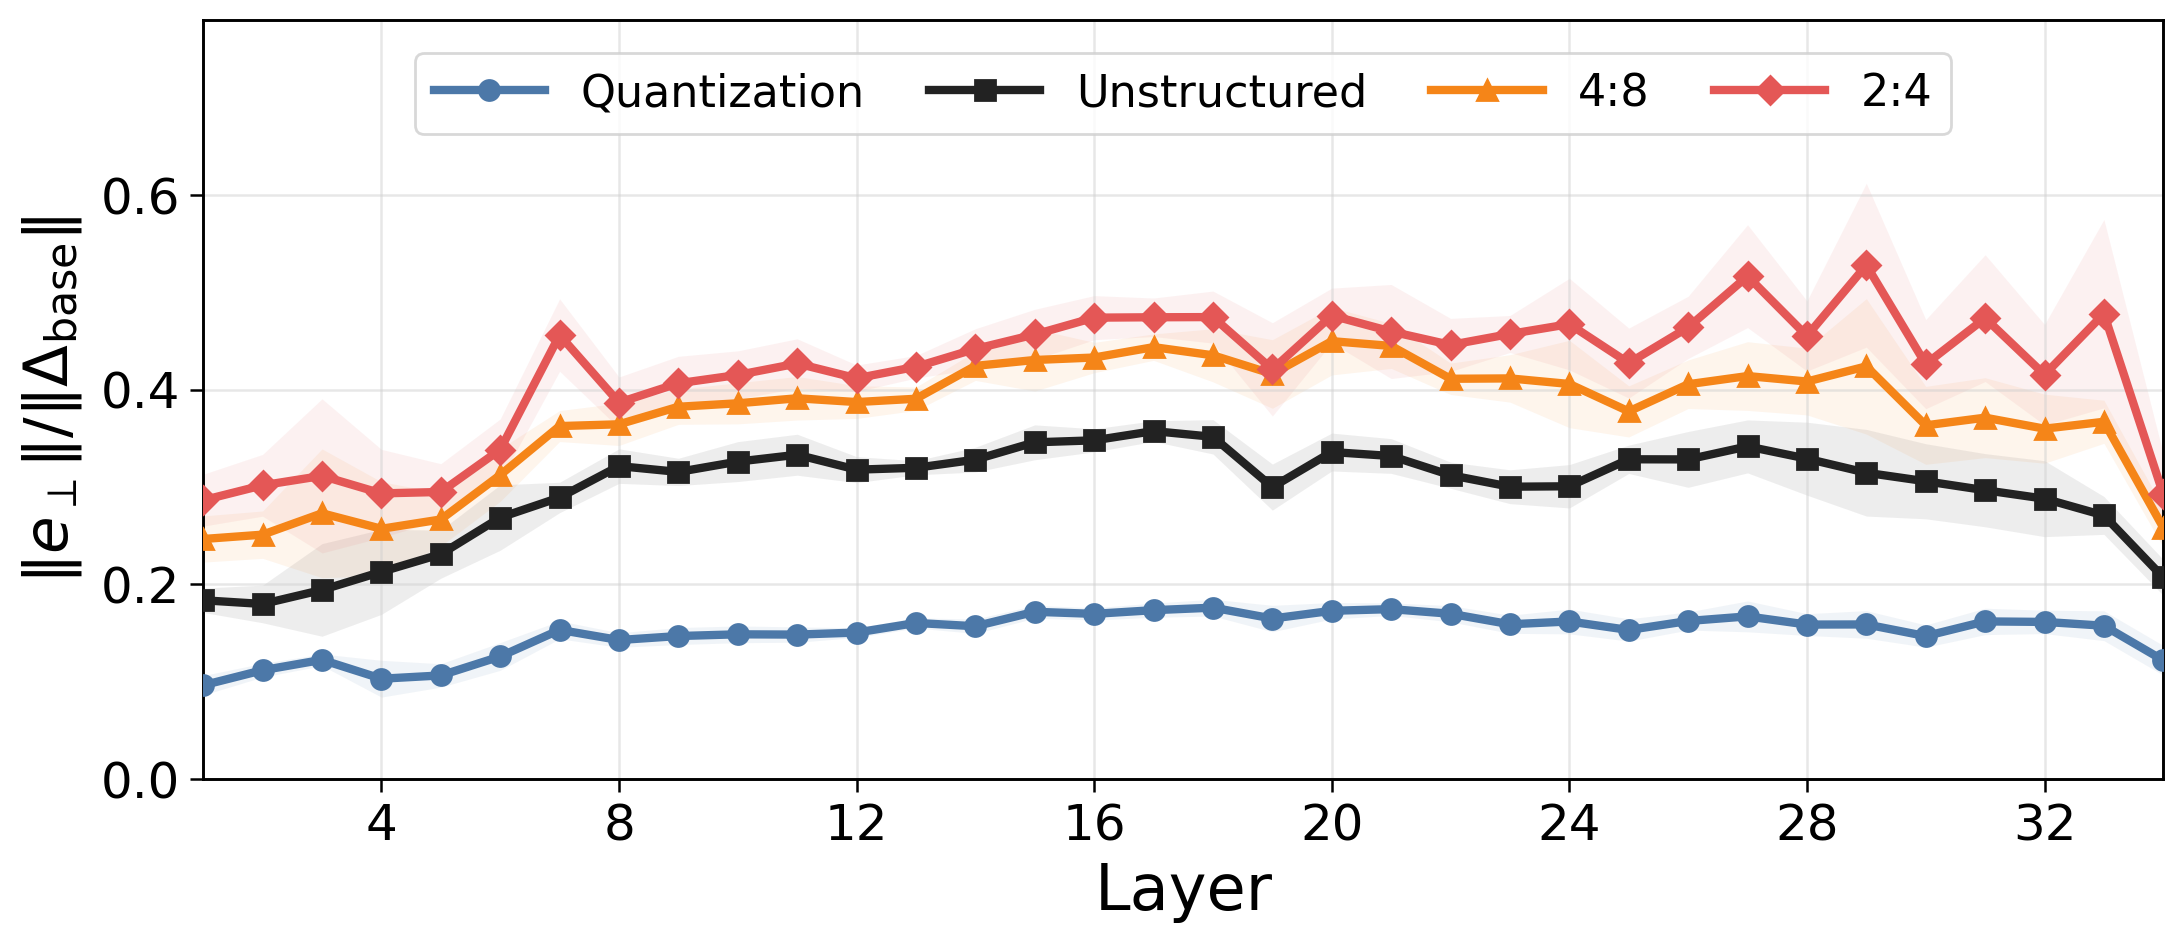

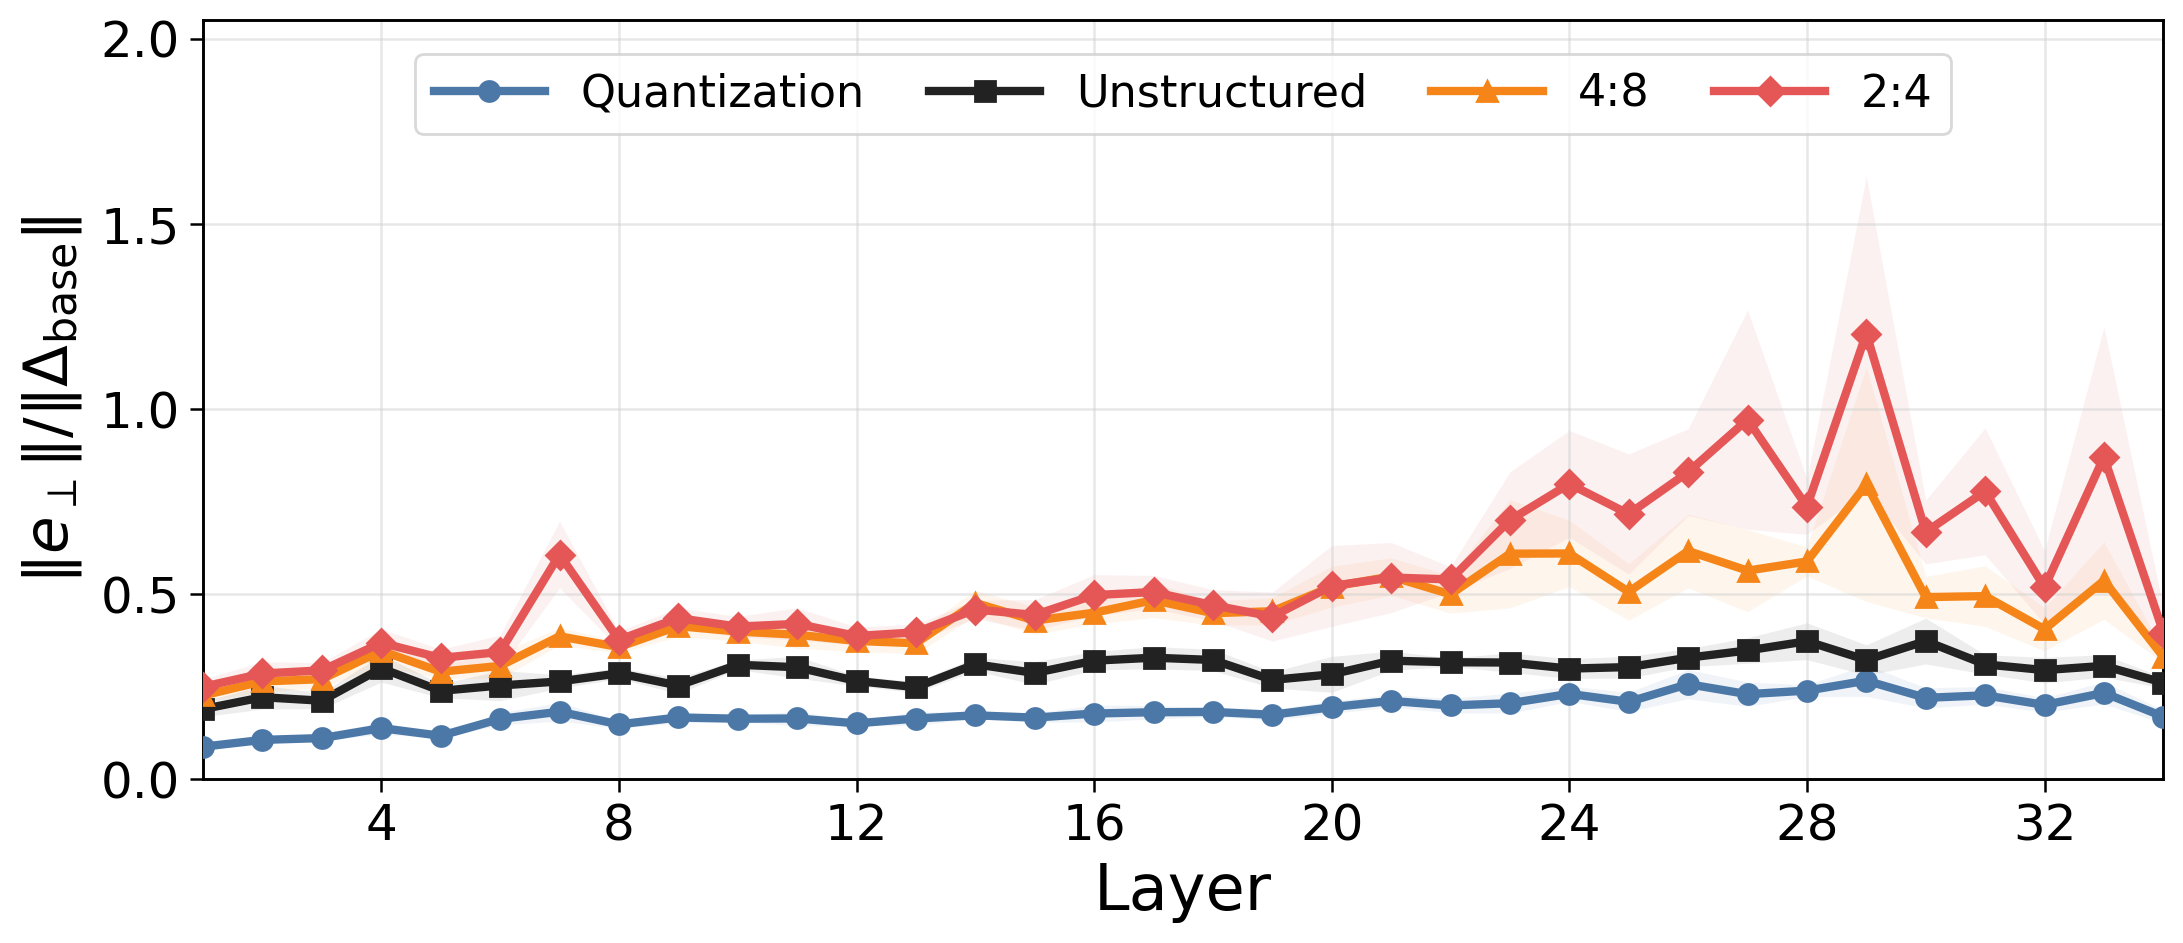

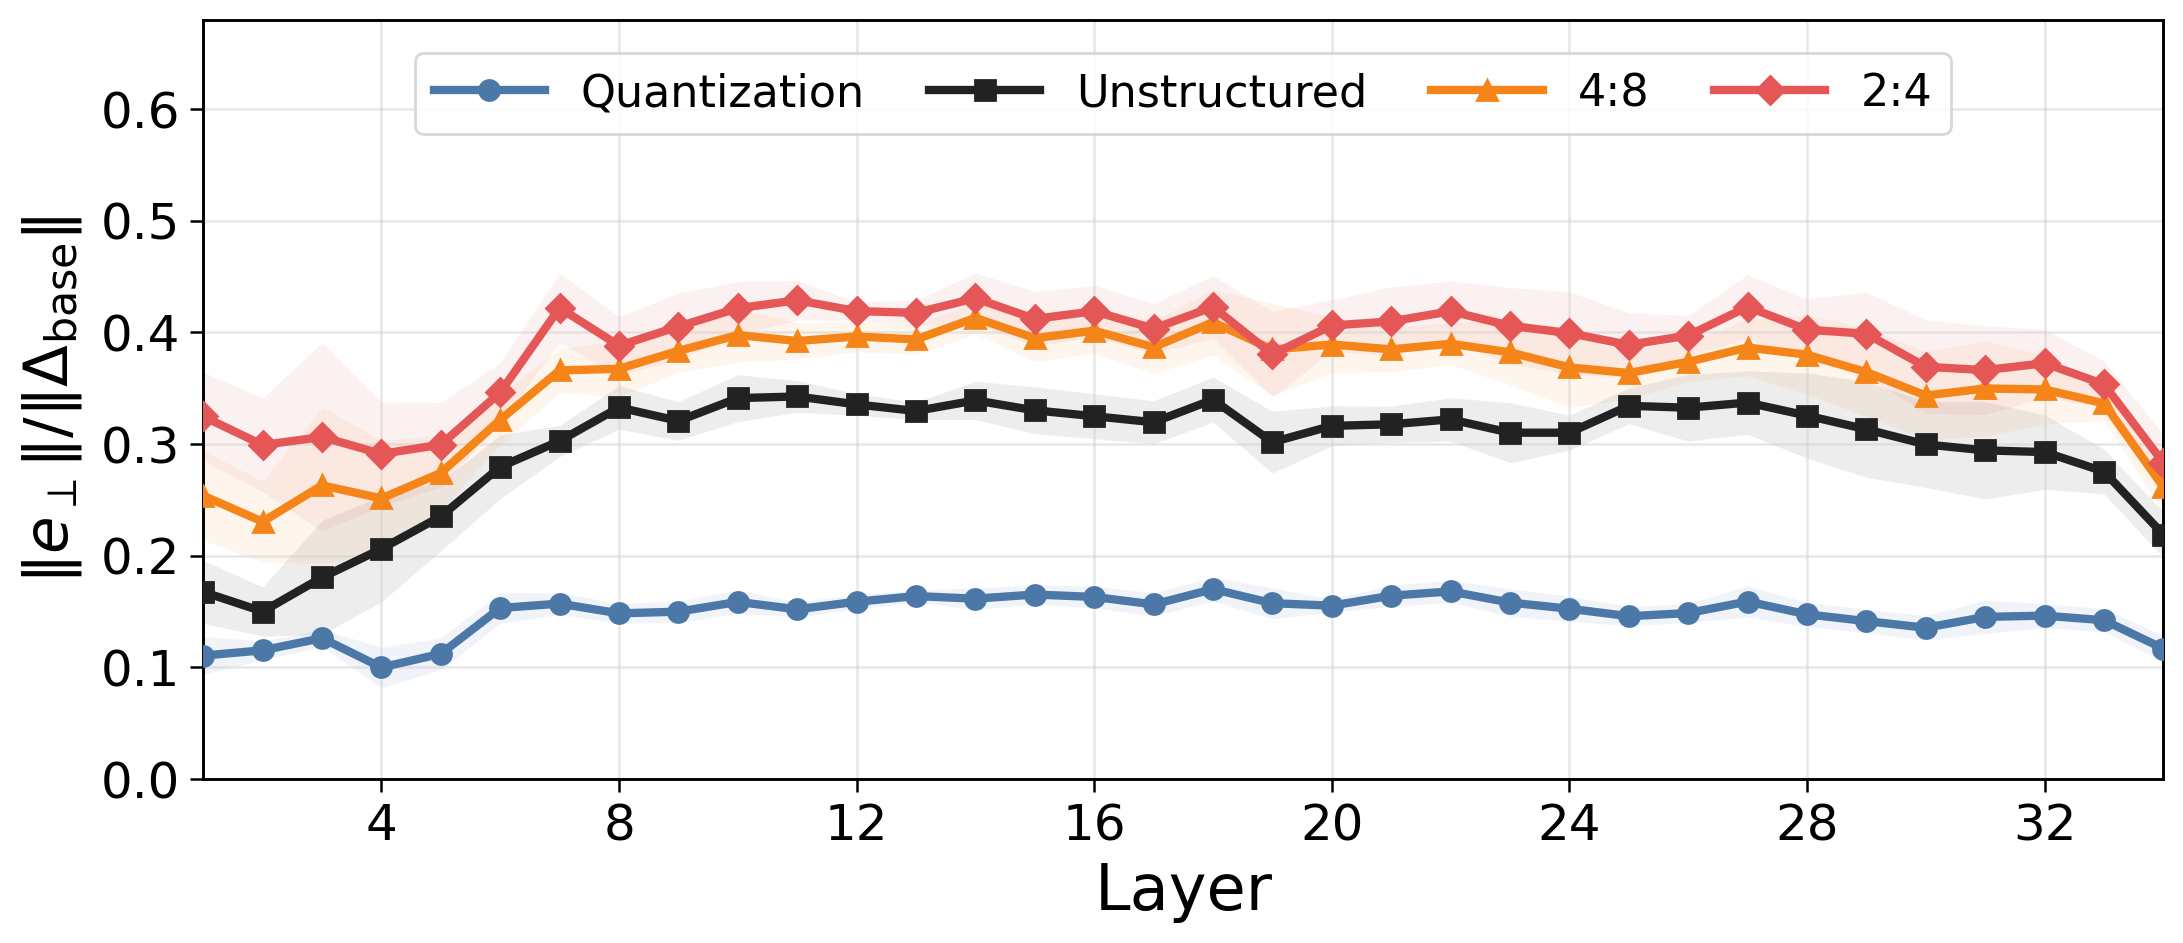

Saved: figs/comp_analysis/local_flip_compare-block_out-perp_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-attn_out-perp_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-mlp_out-perp_over_base_update.pdf


In [64]:
def plot_orthogonal_error(df):
    metric = 'perp_over_base_update'
    ylabel = r'$\|e_{\perp}\| / \|\Delta_{\mathrm{base}}\|$'
    d_all = exclude_edge_layers(df[df['setting'].isin(KEEP_SETTINGS)].copy())
    saved = []

    for comp in COMPONENTS:
        d = d_all[d_all['component'] == comp].copy()
        if d.empty or d[metric].notna().sum() == 0:
            continue

        with plt.rc_context(PLOT_RC):
            fig, ax = plt.subplots(figsize=(10.8, 4.6), dpi=200, constrained_layout=True)
            valid_settings = [s for s in PLOT_ORDER if d[d['setting'] == s][metric].notna().any()]

            for setting in valid_settings:
                g = d[d['setting'] == setting].sort_values('layer')
                style = STYLE_MAP.get(setting, {'color': '#4C78A8', 'marker': 'o'})
                line = ax.plot(
                    g['layer'],
                    g[metric],
                    color=style['color'],
                    marker=style['marker'],
                    linewidth=3.0,
                    markersize=7.2,
                    markeredgewidth=1.0,
                    label=DISPLAY_NAME.get(setting, setting),
                    zorder=3,
                )[0]
                std_col = f'{metric}_std'
                if std_col in g.columns and g[std_col].notna().any():
                    y = g[metric].astype(float)
                    ystd = g[std_col].fillna(0.0).astype(float)
                    ax.fill_between(
                        g['layer'], y - ystd, y + ystd,
                        color=line.get_color(), alpha=0.08, linewidth=0, zorder=1,
                    )

            layers = sorted(d['layer'].dropna().unique().tolist())
            apply_layer_x_axis(ax, layers, min(10, len(layers)))
            ax.set_xlabel('Layer', fontsize=X_LABEL_FONTSIZE)
            ax.set_ylabel(ylabel, fontsize=Y_LABEL_FONTSIZE, labelpad=Y_LABEL_PAD)
            ax.grid(True, color='#d0d0d0', linewidth=0.9, alpha=0.50)
            ax.tick_params(axis='both', which='major', length=4.8, width=0.9)
            ylim = Y_LIM.get(('orthogonal_error', comp), nice_ylim(d[metric]))
            tick_step = Y_TICK_STEP.get(('orthogonal_error', comp))
            apply_y_axis(ax, ylim, tick_step)
            ax.legend(
                loc='upper center', bbox_to_anchor=LEGEND_BBOX,
                ncol=min(4, len(valid_settings)), frameon=True,
                facecolor='white', edgecolor='#cfcfcf', borderpad=0.42,
                handlelength=2.5, columnspacing=1.45,
            )

            for suffix in OUTPUT_SUFFIXES:
                path = OUT_DIR / f'local_flip_compare-{comp}-{metric}.{suffix}'
                fig.savefig(path, bbox_inches='tight', dpi=220 if suffix == 'png' else None)
                saved.append(path)
            plt.show()
    return saved

saved_orthogonal = plot_orthogonal_error(df)
for path in saved_orthogonal:
    print(f'Saved: {path}')


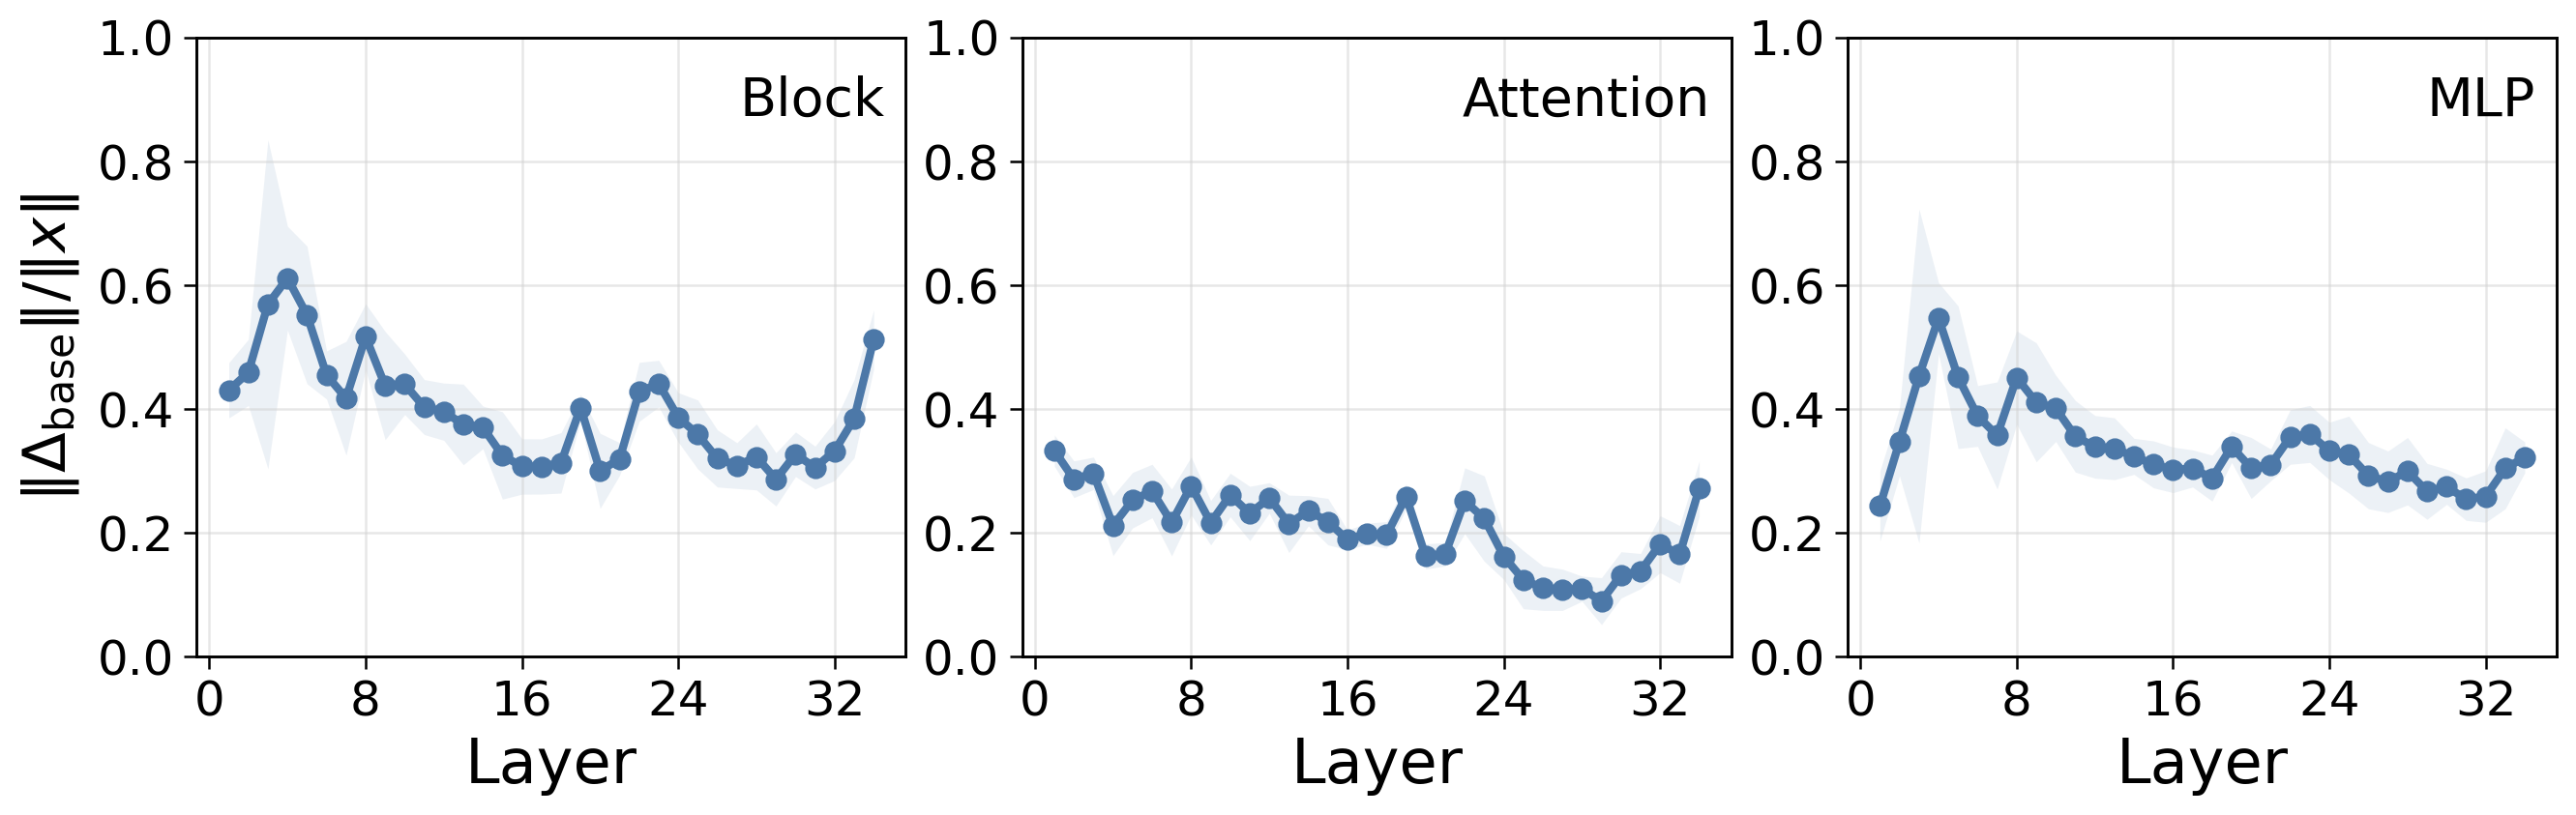

Saved: figs/comp_analysis/baseline_update_over_hidden_state.pdf


In [65]:
def plot_baseline_update_ratio(df):
    metric = 'base_update_over_hidden_state'
    ylabel = r'$\|\Delta_{\mathrm{base}}\| / \|x\|$'
    d = df[df[metric].notna()].copy()
    d = exclude_edge_layers(d)
    if d.empty:
        print('No non-NaN rows for base_update_over_hidden_state.')
        return []

    # This is a dense-baseline property duplicated across WANDA settings.
    d = (
        d.groupby(['component', 'layer'], as_index=False)
        .agg(
            base_update_over_hidden_state=(metric, 'mean'),
            base_update_over_hidden_state_std=(f'{metric}_std', 'mean'),
        )
    )

    saved = []
    with plt.rc_context(PLOT_RC):
        fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1), dpi=200, constrained_layout=True, sharey=False)
        for ax, comp in zip(axes, COMPONENTS):
            g = d[d['component'] == comp].sort_values('layer')
            if g.empty:
                ax.set_visible(False)
                continue
            y = g[metric].astype(float)
            std_col = f'{metric}_std'
            ystd = g[std_col].fillna(0.0).astype(float) if std_col in g.columns else pd.Series(0.0, index=g.index)
            line = ax.plot(
                g['layer'], y,
                color='#4C78A8', marker='o', linewidth=3.0,
                markersize=7.0, markeredgewidth=1.0, zorder=3,
            )[0]
            if std_col in g.columns and g[std_col].notna().any():
                ax.fill_between(
                    g['layer'], y - ystd, y + ystd,
                    color=line.get_color(), alpha=0.10, linewidth=0, zorder=1,
                )
            ax.text(
                0.97, 0.94, COMPONENT_TITLE.get(comp, comp),
                transform=ax.transAxes, ha='right', va='top', fontsize=20,
            )
            ax.set_xlabel('Layer', fontsize=X_LABEL_FONTSIZE)
            ax.grid(True, color='#d0d0d0', linewidth=0.9, alpha=0.50)
            ax.tick_params(axis='both', which='major', length=4.8, width=0.9)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
            auto_ylim = centered_ylim(y - ystd, y + ystd)
            ylim = Y_LIM.get(('baseline_update_ratio', comp), auto_ylim)
            tick_step = Y_TICK_STEP.get(('baseline_update_ratio', comp))
            apply_y_axis(ax, ylim, tick_step)

        axes[0].set_ylabel(ylabel, fontsize=Y_LABEL_FONTSIZE, labelpad=Y_LABEL_PAD)

        for suffix in OUTPUT_SUFFIXES:
            path = OUT_DIR / f'baseline_update_over_hidden_state.{suffix}'
            fig.savefig(path, bbox_inches='tight', dpi=220 if suffix == 'png' else None)
            saved.append(path)
        plt.show()
    return saved

saved_baseline_ratio = plot_baseline_update_ratio(df)
for path in saved_baseline_ratio:
    print(f'Saved: {path}')


In [66]:
print('Figure directory:', OUT_DIR)
print('Generated files:')
for path in sorted(OUT_DIR.glob('*.pdf')):
    print(' ', path.name)


Figure directory: figs/comp_analysis
Generated files:
  baseline_update_over_hidden_state.pdf
  local_flip_compare-attn_out-error_over_base_update.pdf
  local_flip_compare-attn_out-para_over_base_update.pdf
  local_flip_compare-attn_out-perp_over_base_update.pdf
  local_flip_compare-attn_out-perp_over_x.pdf
  local_flip_compare-block_out-error_over_base_update.pdf
  local_flip_compare-block_out-para_over_base_update.pdf
  local_flip_compare-block_out-perp_over_base_update.pdf
  local_flip_compare-mlp_out-error_over_base_update.pdf
  local_flip_compare-mlp_out-para_over_base_update.pdf
  local_flip_compare-mlp_out-perp_over_base_update.pdf
  local_flip_compare_v1-attn_out-perp_over_x.pdf
  local_flip_compare_v1-block_out-perp_over_x.pdf
  local_flip_compare_v1-mlp_out-perp_over_x.pdf


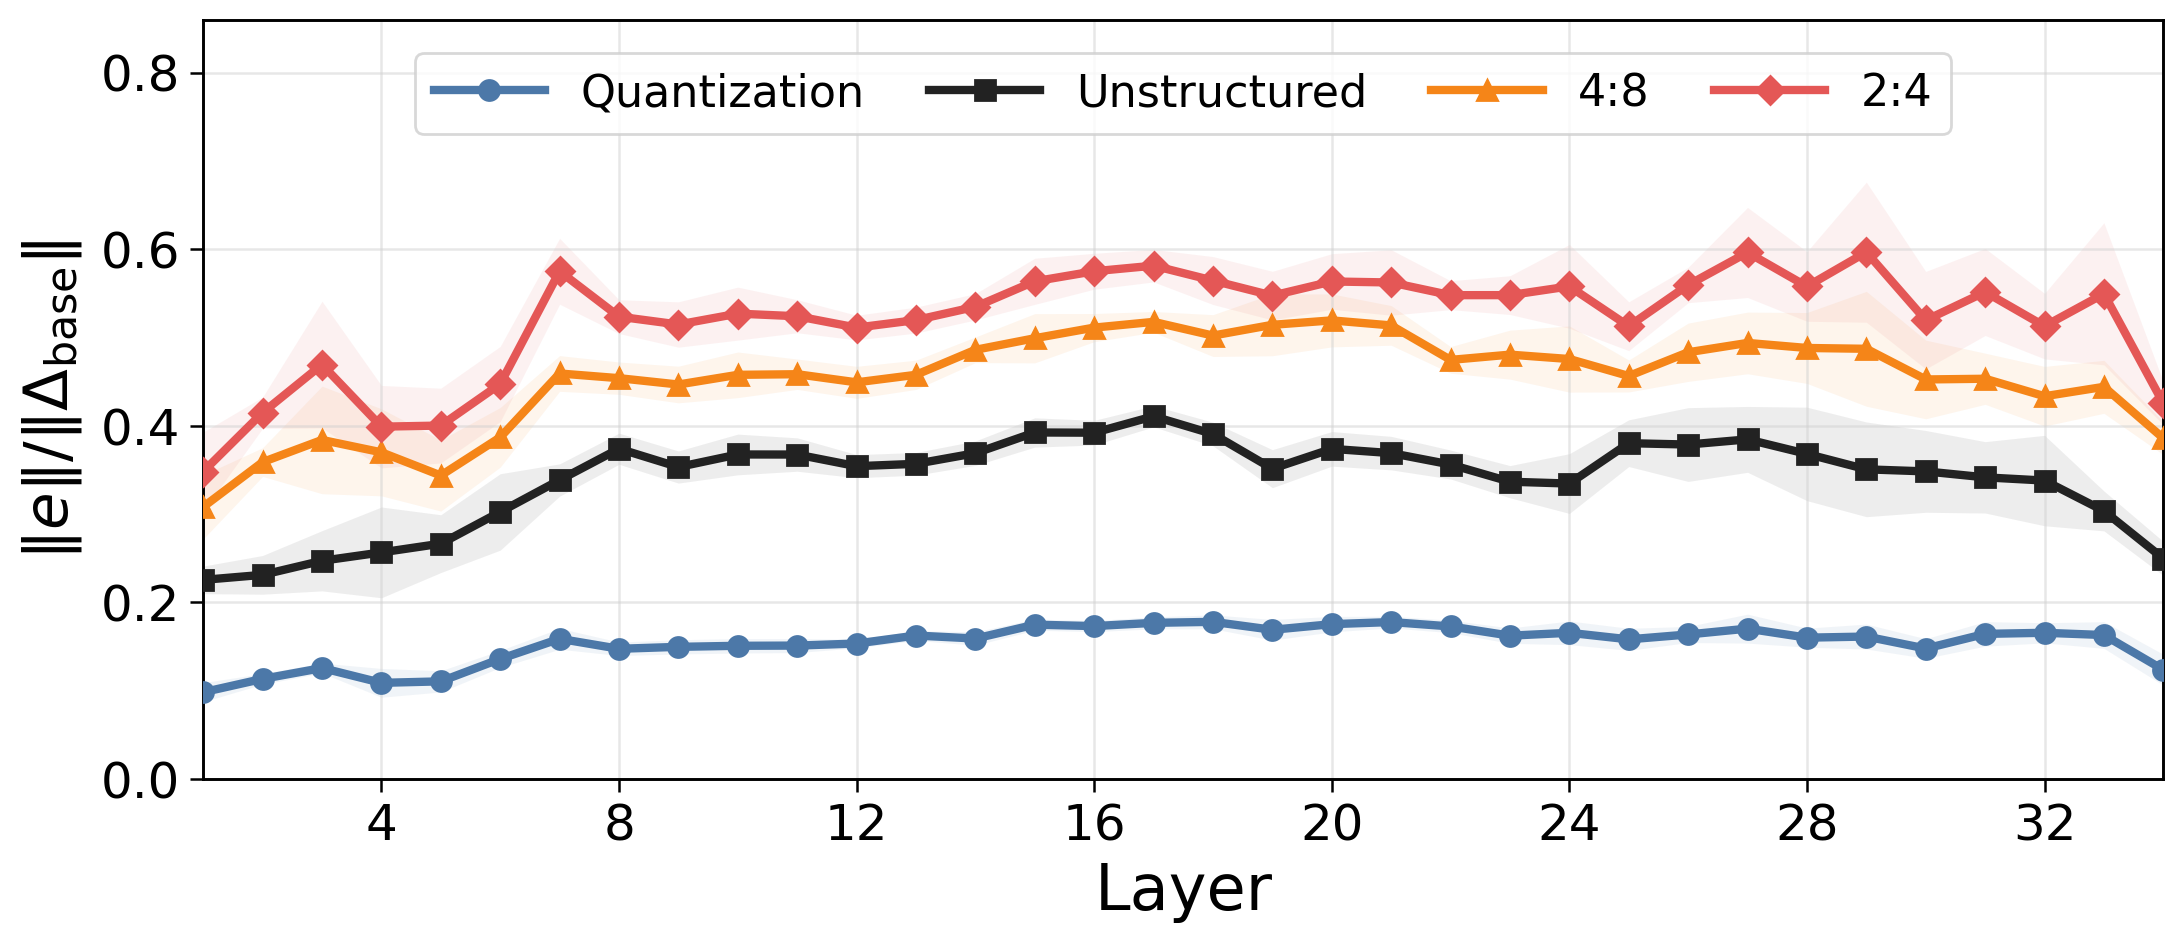

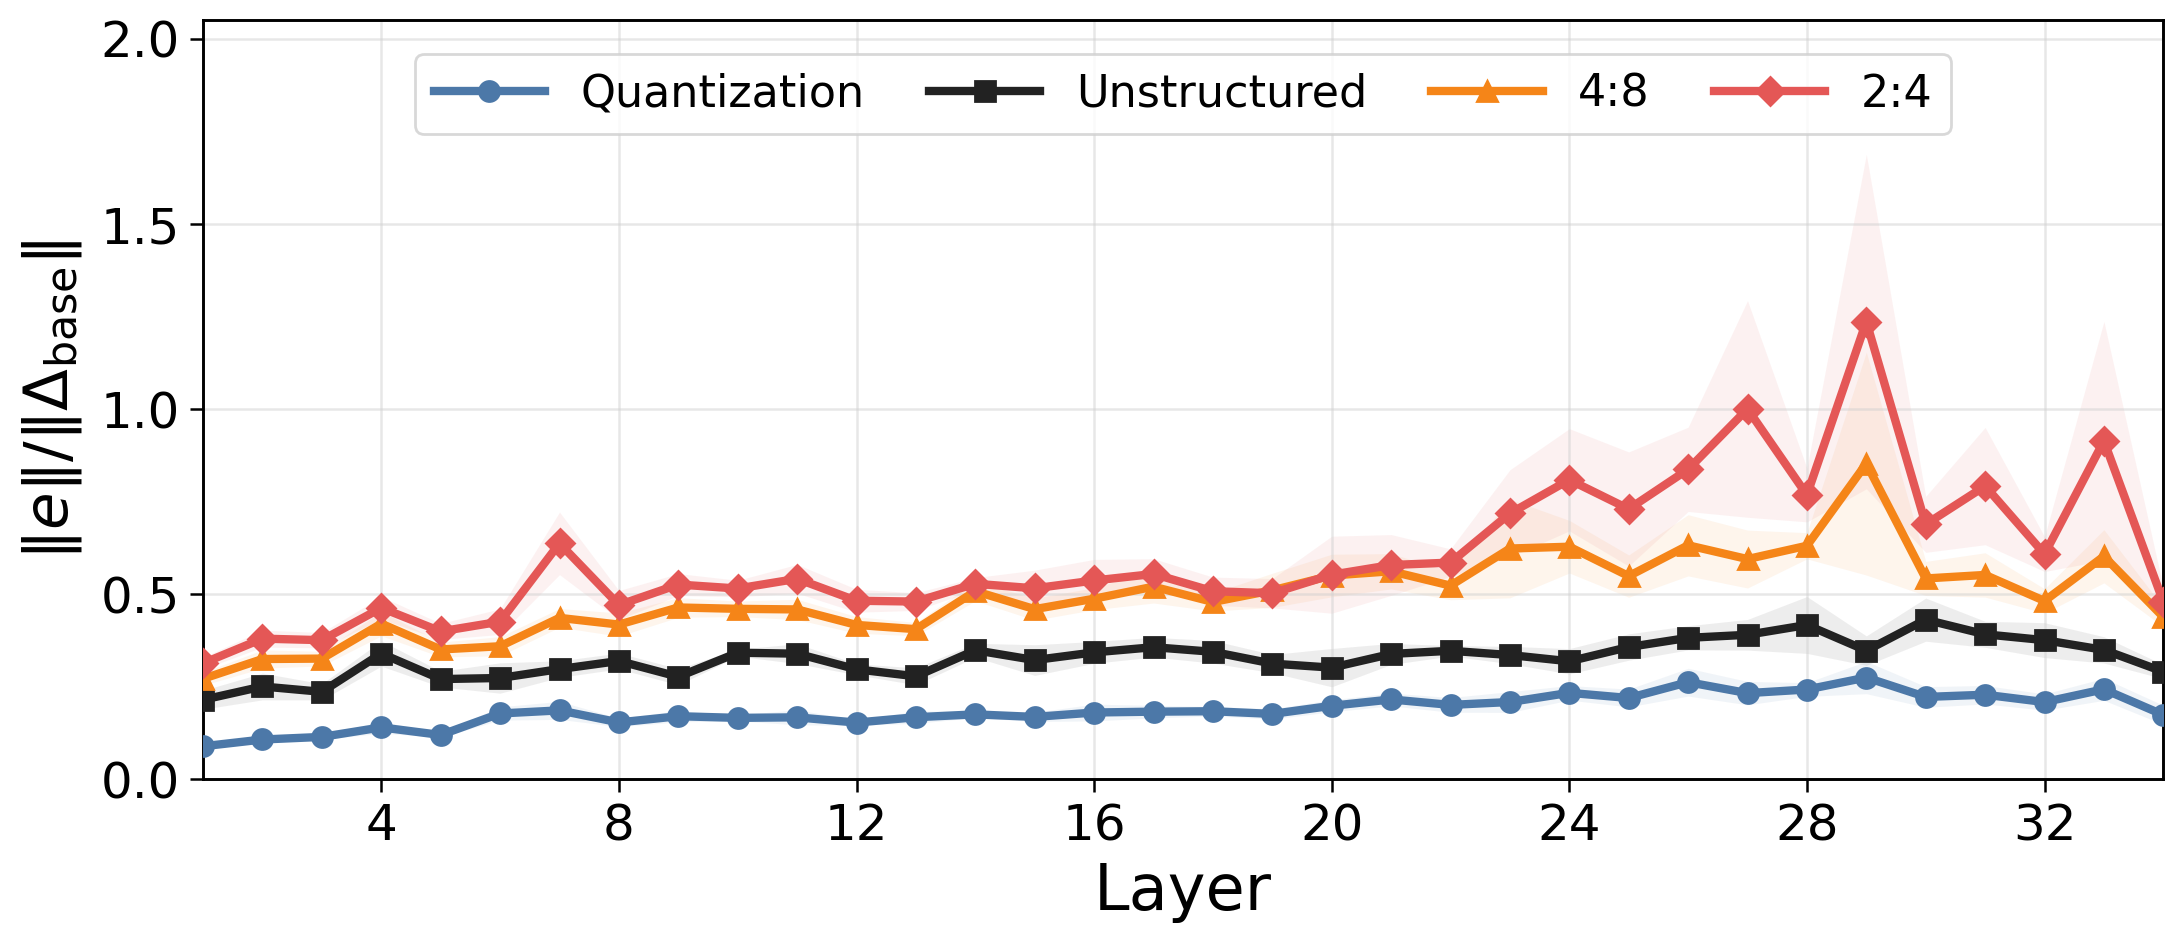

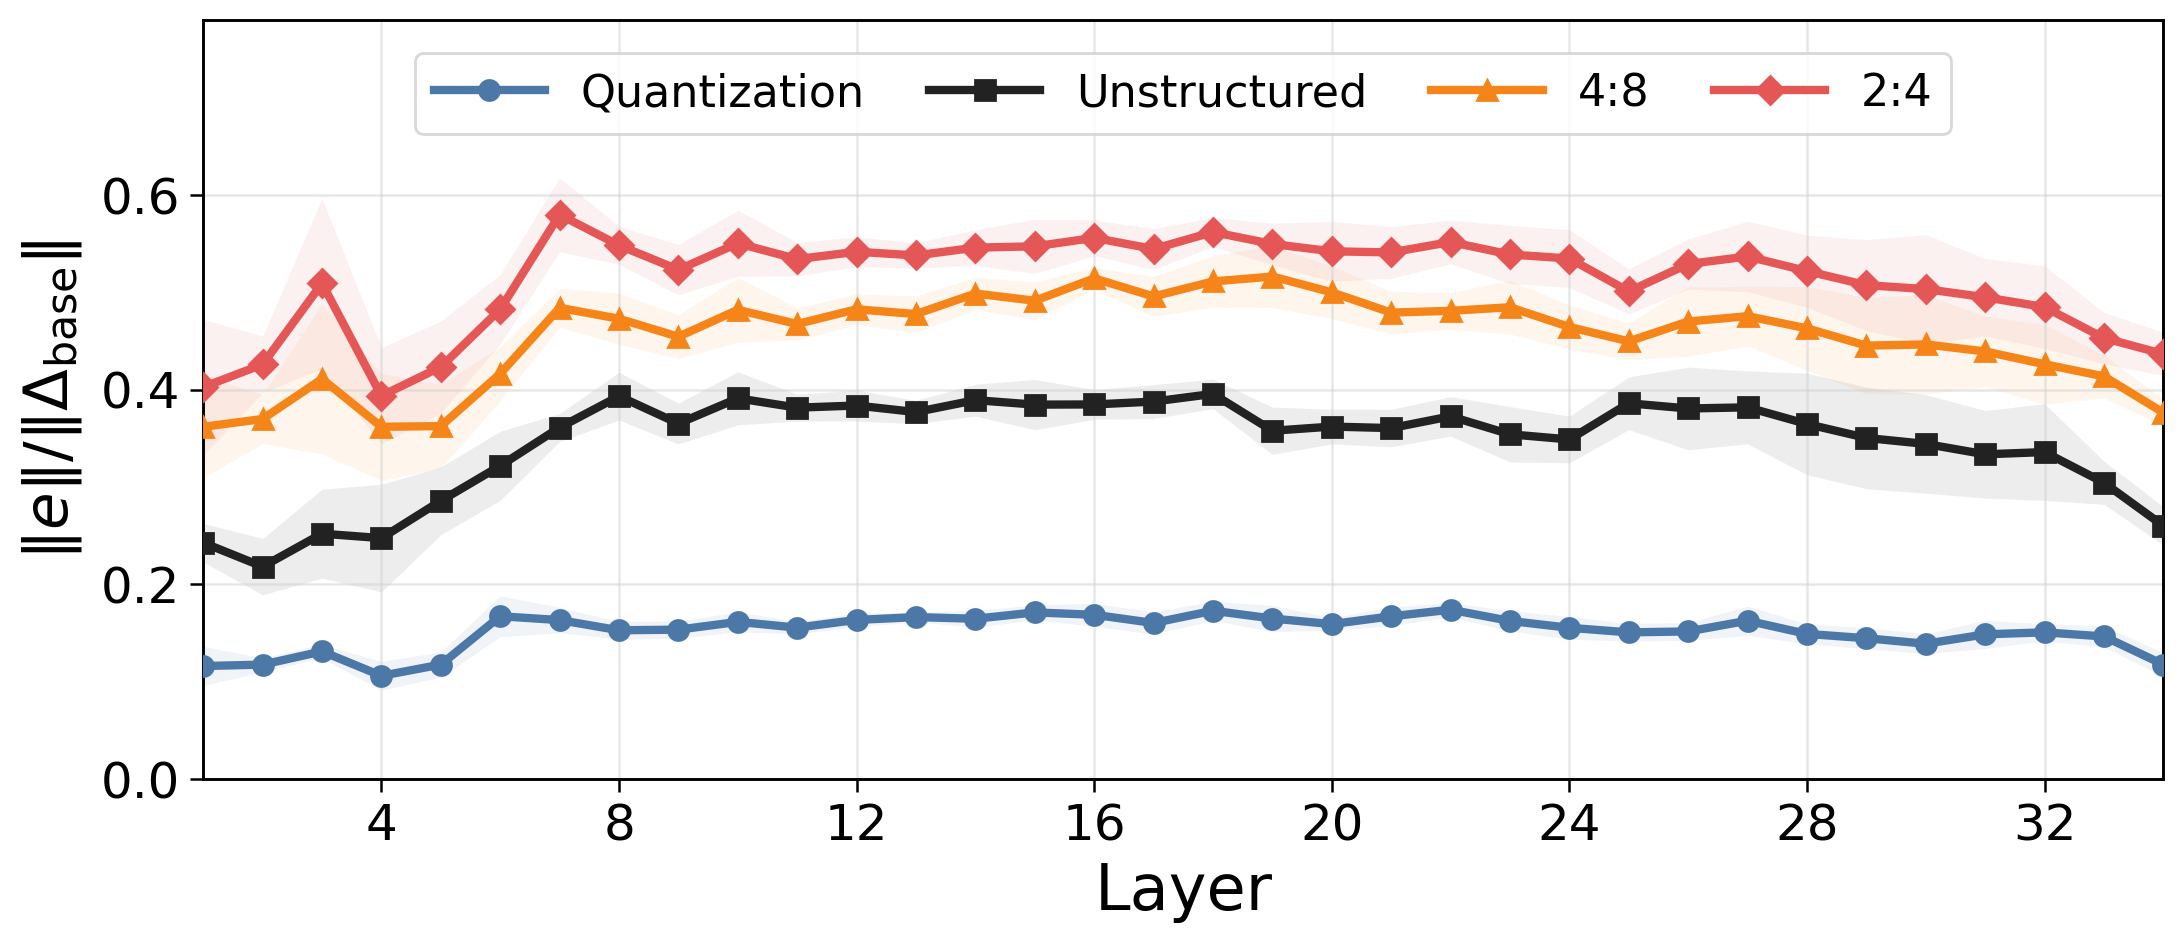

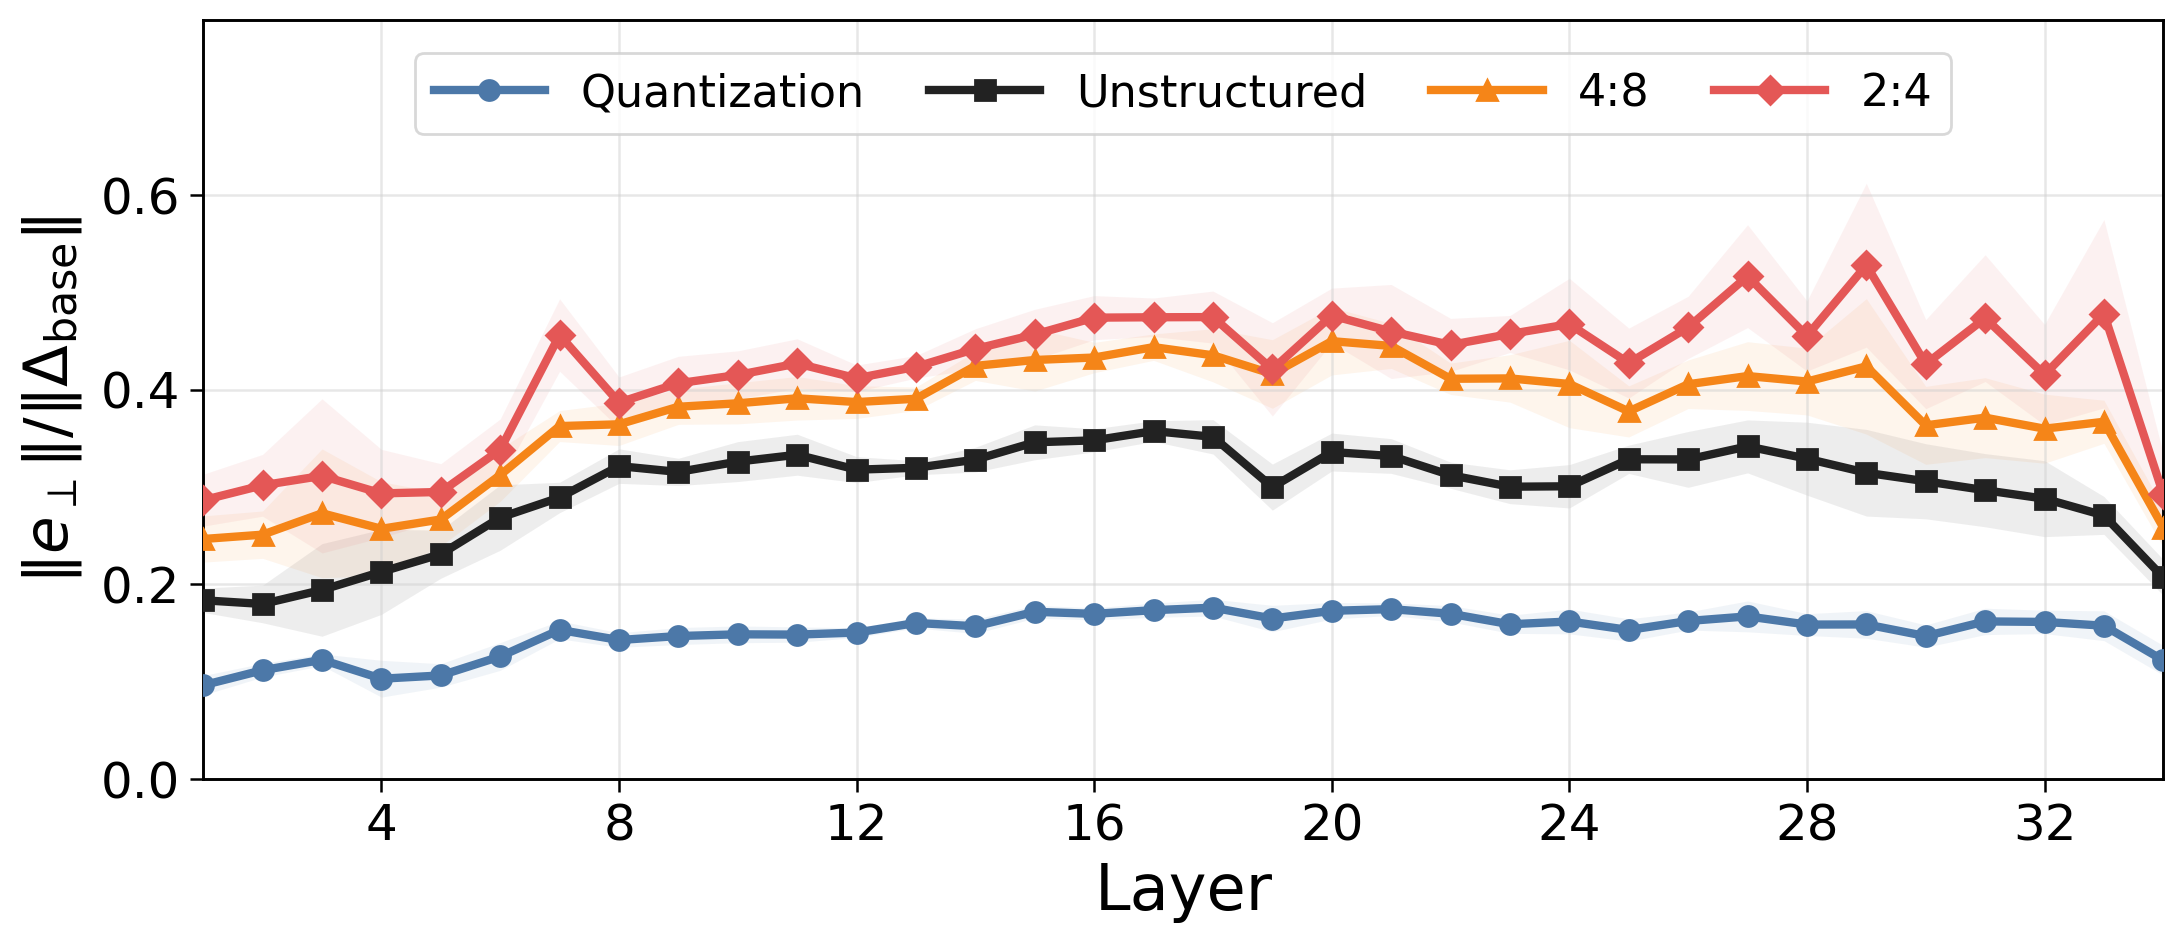

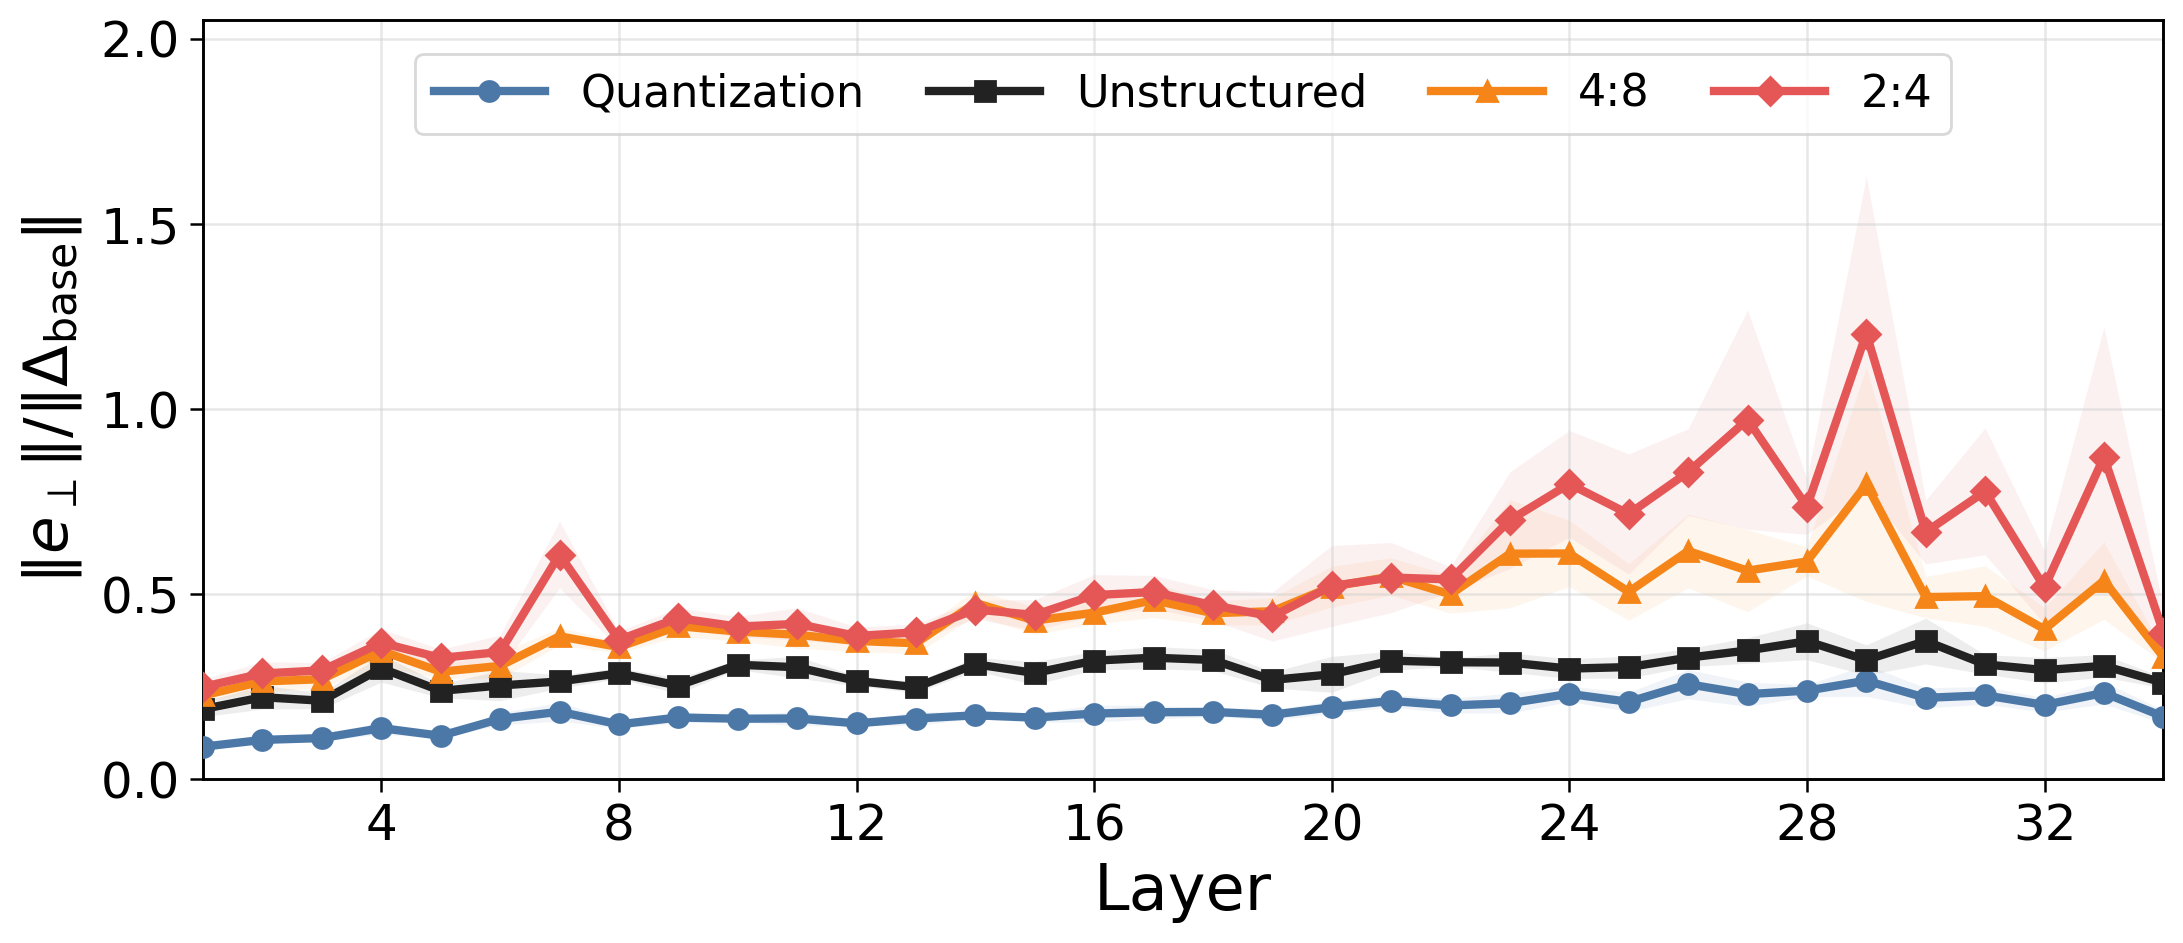

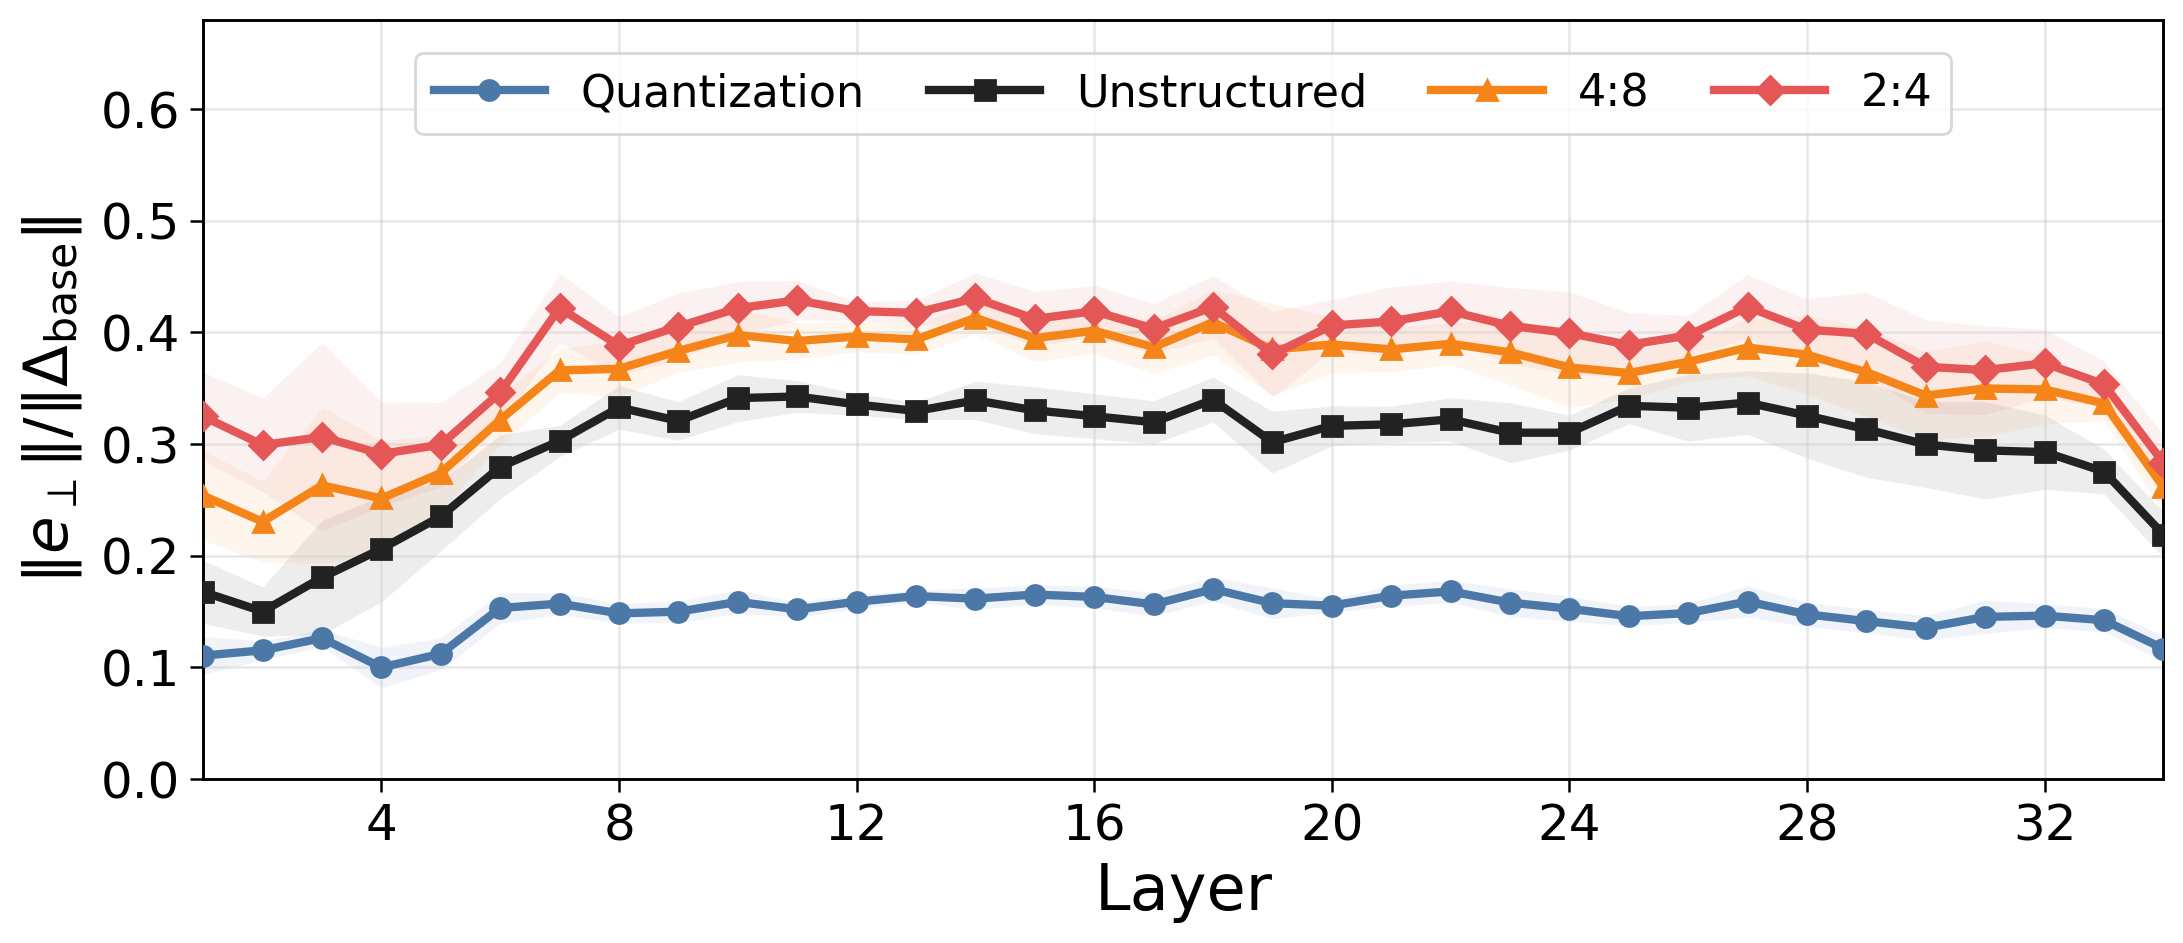

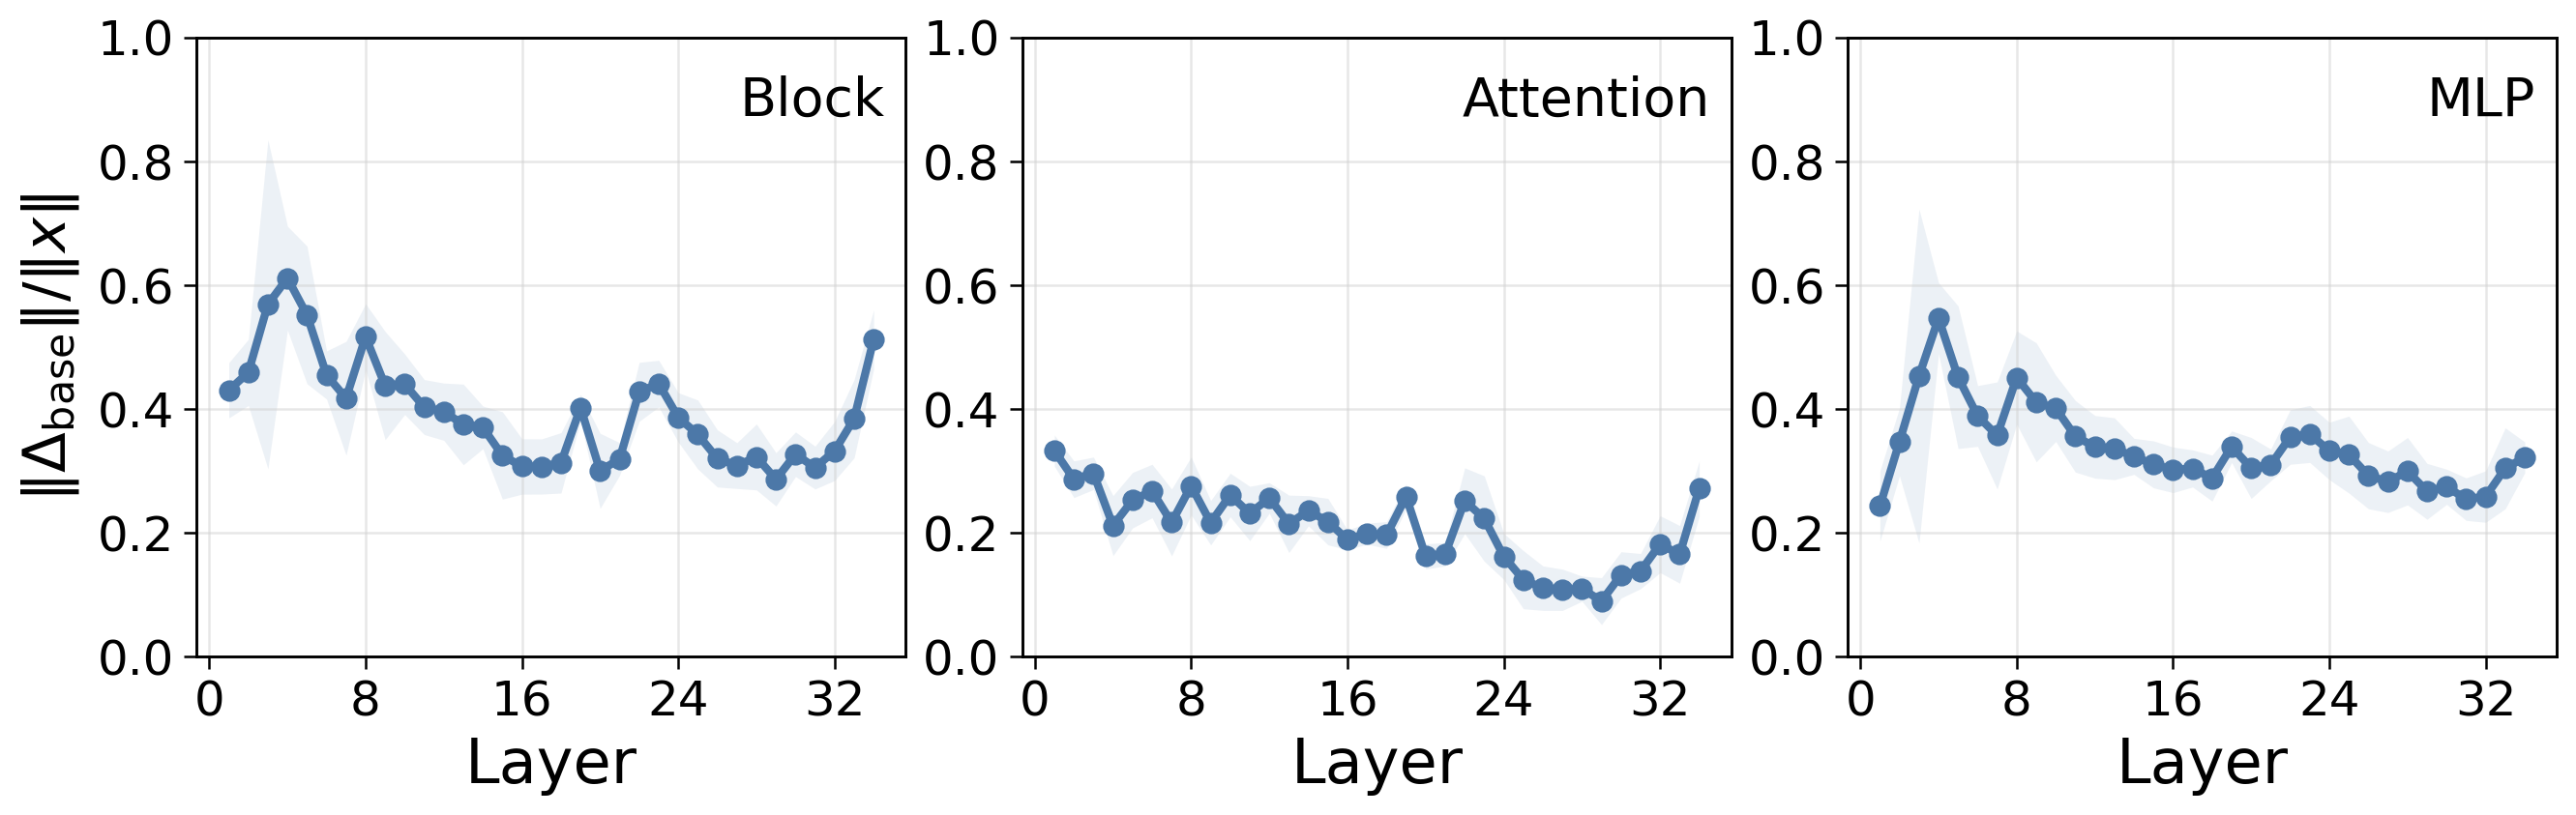

Previewed figures in notebook and saved to: figs/comp_analysis
Saved: figs/comp_analysis/local_flip_compare-block_out-error_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-attn_out-error_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-mlp_out-error_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-block_out-perp_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-attn_out-perp_over_base_update.pdf
Saved: figs/comp_analysis/local_flip_compare-mlp_out-perp_over_base_update.pdf
Saved: figs/comp_analysis/baseline_update_over_hidden_state.pdf


In [67]:
# Rerun this cell after changing *_Y_LIM to preview all figures inside the notebook.
saved_total = plot_total_error(df)
saved_orthogonal = plot_orthogonal_error(df)
saved_baseline_ratio = plot_baseline_update_ratio(df)
if PLOT_PARALLEL_ERROR:
    saved_parallel = plot_parallel_error(df)
else:
    saved_parallel = []
print('Previewed figures in notebook and saved to:', OUT_DIR)
for path in [*saved_total, *saved_orthogonal, *saved_baseline_ratio, *saved_parallel]:
    print('Saved:', path)


In [68]:
def plot_parallel_error(df):
    metric = 'para_over_base_update'
    ylabel = r'$\|e_{\parallel}\| / \|\Delta_{\mathrm{base}}\|$'
    d_all = exclude_edge_layers(df[df['setting'].isin(KEEP_SETTINGS)].copy())
    saved = []

    for comp in COMPONENTS:
        d = d_all[d_all['component'] == comp].copy()
        if d.empty or d[metric].notna().sum() == 0:
            continue

        with plt.rc_context(PLOT_RC):
            fig, ax = plt.subplots(figsize=(10.8, 4.6), dpi=200, constrained_layout=True)
            valid_settings = [s for s in PLOT_ORDER if d[d['setting'] == s][metric].notna().any()]

            for setting in valid_settings:
                g = d[d['setting'] == setting].sort_values('layer')
                style = STYLE_MAP.get(setting, {'color': '#4C78A8', 'marker': 'o'})
                line = ax.plot(
                    g['layer'],
                    g[metric],
                    color=style['color'],
                    marker=style['marker'],
                    linewidth=3.0,
                    markersize=7.2,
                    markeredgewidth=1.0,
                    label=DISPLAY_NAME.get(setting, setting),
                    zorder=3,
                )[0]
                std_col = f'{metric}_std'
                if std_col in g.columns and g[std_col].notna().any():
                    y = g[metric].astype(float)
                    ystd = g[std_col].fillna(0.0).astype(float)
                    ax.fill_between(
                        g['layer'], y - ystd, y + ystd,
                        color=line.get_color(), alpha=0.08, linewidth=0, zorder=1,
                    )

            layers = sorted(d['layer'].dropna().unique().tolist())
            apply_layer_x_axis(ax, layers, min(10, len(layers)))
            ax.set_xlabel('Layer', fontsize=X_LABEL_FONTSIZE)
            ax.set_ylabel(ylabel, fontsize=Y_LABEL_FONTSIZE, labelpad=Y_LABEL_PAD)
            ax.grid(True, color='#d0d0d0', linewidth=0.9, alpha=0.50)
            ax.tick_params(axis='both', which='major', length=4.8, width=0.9)
            ylim = PARA_Y_LIM.get(('parallel_error', comp), nice_ylim(d[metric]))
            tick_step = PARA_Y_TICK_STEP.get(('parallel_error', comp))
            apply_y_axis(ax, ylim, tick_step)
            ax.legend(
                loc='upper center', bbox_to_anchor=LEGEND_BBOX,
                ncol=min(4, len(valid_settings)), frameon=True,
                facecolor='white', edgecolor='#cfcfcf', borderpad=0.42,
                handlelength=2.5, columnspacing=1.45,
            )

            for suffix in OUTPUT_SUFFIXES:
                path = OUT_DIR / f'local_flip_compare-{comp}-{metric}.{suffix}'
                fig.savefig(path, bbox_inches='tight', dpi=220 if suffix == 'png' else None)
                saved.append(path)
            plt.show()
    return saved

if PLOT_PARALLEL_ERROR:
    saved_parallel = plot_parallel_error(df)
    for path in saved_parallel:
        print(f'Saved: {path}')
